# Colab Base para el Trabajo Práctico (Entrega 3)



## Informe del notebook

Este notebook realiza un flujo completo de preparación de datos, detección de outliers, ingeniería de variables, selección y entrenamiento de modelo, y generación de una solución para subir a Kaggle.

### Pasos principales realizados

1. **Lectura de datos**
   - Importa datos de entrenamiento desde `data/raw/entrenamiento.csv`.
   - Carga los datos a predecir desde `data/a_predecir.csv`.

2. **Filtrado inicial**
   - Filtra el dataset de entrenamiento por país, provincia, tipo de operación, tipo de propiedad, moneda y rango de precio.
   - El objetivo es trabajar solo con casos de `venta` en `dólares` y propiedades residenciales válidas.

3. **Ingeniería de variables**
   - Crea la columna `texto` uniendo `features` y `description` en minúsculas.
   - Extrae variables numéricas desde el texto: `c_dormitorios`, `c_baños`, `c_ambientes`, `superficie`.
   - Genera indicadores binarios para amenidades como `con_pileta`, `con_garage`, `con_ascensor`, `con_parque`, `a_estrenar`, etc.
   - Estandariza `property_type` reemplazando `casas` por `casa` y `departamentos` por `departamento`.

4. **Precio por metro cuadrado**
   - Calcula `price_m2 = price / superficie`.
   - Agrupa por `property_type` y `location_2` para obtener el promedio de `price_m2` por barrio.
   - Mezcla ese promedio de vuelta al dataset.

5. **Codificación de variables categóricas**
   - Genera variables dummy para `property_type`.
   - En la parte de predicción, también codifica `property_type` con `get_dummies()`.

6. **Detección y eliminación de outliers**
   - Define función `detect_atipico_iqr()` usando el método IQR.
   - Detecta outliers por precio de `departamento` y `casa` por separado.
   - Detecta outliers por `superficie`, `cantidad de baños` y `ambientes`.
   - Alinea las máscaras booleanas con el índice original y elimina las filas outlier de `df_ent`.

7. **Imputación de valores faltantes**
   - Imputa valores nulos de `address`, `description`, `features`, `location_3`, `location_4`, `source` con valores de texto.
   - Imputa `publication_date` y `publisher_id` con la moda.
   - Imputa `c_dormitorios`, `c_baños`, `c_ambientes` con la moda.
   - Imputa `superficie` con el promedio.
   - Recalcula medias de `lon` y `lat` por `location_2`.

8. **Reducción de dimensionalidad y selección de variables**
   - Aplica `SelectKBest(chi2)`, correlación y RFE para explorar qué variables son más relevantes.
   - Utiliza `RandomForestRegressor` para seleccionar características.

9. **Entrenamiento del modelo**
   - Ajusta un `RandomForestRegressor` con `train_test_split`.
   - Calcula errores RMSE en entrenamiento y prueba.
   - Incluye una sección opcional de búsqueda de hiperparámetros con `GridSearchCV`.

10. **Generación de la solución para Kaggle**
    - Aplica la misma transformación al dataset `df_ap`.
    - Predice `price` con el modelo entrenado.
    - Guarda las predicciones en un archivo CSV de salida.

### Observaciones

- El notebook mezcla operaciones de exploración, limpieza y modelado en un solo flujo.
- La parte crítica es mantener la alineación de índices cuando se calculan outliers por subconjuntos.
- El informe resume cada bloque de trabajo y permite seguir el proceso de preparación hasta la entrega.


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn import model_selection
from sklearn import ensemble
from sklearn import metrics
import geopandas as gpd
from shapely.geometry import Point

# import spacy

# import locale
# locale.getpreferredencoding = lambda: "UTF-8"

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Lectura de datos

In [2]:
# TODO: Cambiar para que apunte al directorio correcto
DIR_colab = "/content/drive/MyDrive" + "/UBA/Especializacion/DM/Data"
DIR_local = "../data"

engine = sqlite3.connect(f"{DIR_local}/entrenamiento.db")

df_ent = pd.read_sql("SELECT * FROM entrenamiento", engine, index_col="id")

## 1.Entender los datos (AID)
```python
df_ent.columns
df_ent.shape()
df_ent.describe()
df_ent.info()

print(f"Dataset a predecir - Operaciones:\n-{df_ap.operation_type.unique()}\n")
print(f"Dataset a entrenar - Operaciones:\n-{df_ent.operation_type.unique()}")
print("-"*90)

print(f"Dataset a predecir - Propiedad:\n-{df_ap.property_type.unique()}\n")
print(f"Dataset a entrenar - Propiedad:\n-{df_ent.property_type.unique()}")
print("-"*90)

print(f"Dataset a predecir - País:\n-{df_ap.location_0.unique()}\n")
print(f"Dataset a entrenar - País:\n-{df_ent.location_0.unique()}\n")
print("-"*90)
print(f"Dataset a predecir - Provincia:\n-{df_ap.location_1.unique()}\n")
print(f"Dataset a entrenar - Provincia:\n-{df_ent.location_1.unique()}\n")
print("-"*90)
print(f"Dataset a predecir - Ciudad:\n-{df_ap.location_2.unique()}\n")
print(f"Dataset a entrenar - Ciudad:\n-{df_ent.location_2.unique()}")
print("-"*90)

print(f"Dataset a predecir - Moneda:\n-{df_ap.currency_type.unique()}\n")
print(f"Dataset a entrenar - Moneda:\n-{df_ent.currency_type.unique()}\n")
print("-"*90)
print(f"Dataset a predecir - Fuente de datos:\n-{df_ap.source.unique()}\n")
print(f"Dataset a entrenar - Fuente de datos:\n-{df_ent.source.unique()}\n")
print("-"*90)
```

## 2.Limpiar y transformar los datos (DM)

## 2.1. Filtrado de datos
``` python
# Selección de datos. Solo a fines demostrativos.
# TODO: CAMBIAR!
# Entrenamiento se basa en los parámentreos lon y lat, este filtro lo haremos por geolocalización,
#  operación, tipo de propiedad, moneda, fuente de datos
filtro = ((df_ent["location_0"] == 'Argentina') &
 (df_ent["location_1"].isin(['Ciudad Autónoma de Buenos Aires','Capital Federal', 'CABA'])) &
          (df_ent["operation_type"] == "venta") &
          (df_ent["property_type"].isin(['casa','departamento', "departamentos", "casas"])) &
          (df_ent["currency_type"].isin(['dolares']))   &
          (df_ent["price" ] < 700000) &
          (~df_ent["price"].isna()) &
           (df_ent["price"]!=0))
df_ent = df_ent.loc[filtro]
df_ent.shape
```


Una vez definido el filtrado de información, se guarda el dataset en un csv. De forma tal, que en los próximos análisis, evite la conexión a la base de datos y el proceso de filtrado.
```python
# Guardo el dataframe en un csv, para luego acceder más facil.
df_ent.to_csv("/content/drive/MyDrive/UBA/Especializacion/DM/Data/raw/entrenamiento.csv")
```

In [5]:
df_ent.shape

(1292674, 17)

In [3]:
filtro = ((df_ent["location_0"] == 'Argentina') &
 (df_ent["location_1"].isin(['Ciudad Autónoma de Buenos Aires','Capital Federal', 'CABA'])) &
          (df_ent["operation_type"] == "venta") &
          (df_ent["property_type"].isin(['departamento', "departamentos"])) &
          (df_ent["currency_type"].isin(['dolares']))   &
        #   (df_ent["price" ] < 700000) &
          (~df_ent["price"].isna()) &
           (df_ent["price"]!=0))
df_ent = df_ent.loc[filtro]
df_ent.shape

(104580, 17)

## 2.2 Creación de nuevos atributos

Para poder ver la tablas en un ancho definido y no  acotada. Esto mejora la visualización

In [55]:
# Muestra sin restricción
pd.set_option('display.max_colwidth', None)
# retoran a la configuración de fábrica
# pd.reset_option('display.max_colwidth')

**Anáisis del atributo features**

con el comando extract utilizando expresiones regulares.\
Atributos posibles:


*   baños
*   dormitorios
*   superficie
*   superficie cubierta




In [4]:
# creamos otras variables
texto = (
    df_ent["features"].fillna("").astype(str) + " " +
    df_ent["description"].fillna("").astype(str)
)
# pasamos a minúscula para evitar problemas de mayúsculas/minúsculas
texto = texto.str.lower()
df_ent["texto"] = texto
# df_ent["texto"].head() 



In [5]:

# dormitorios
patron = r"(\d+) dormitorios;|dormitorio: (\d+);|dormitorios:(\d+);|(\d+)\s*habitaciones"
dormitorios = texto.str.extract(patron, expand=False)
df_ent["c_dormitorios"] = pd.to_numeric(dormitorios[0].fillna(dormitorios[1]).fillna(dormitorios[2]).fillna(dormitorios[3]))

#
# baños
patron = r"(\d+) baños;|bano: (\d+);|baños:(\d+);|(\d+)\s*banos"
banios = texto.str.extract(patron, expand=False)
df_ent["c_baños"] = pd.to_numeric(banios[0].fillna(banios[1]).fillna(banios[2]).fillna(banios[3]))

# ambientes
patron = r"(\d+)\s*(?:ambientes?|rooms?)"
ambientes = texto.str.extract(patron, expand=False)
df_ent["c_ambientes"] = pd.to_numeric(ambientes)


# # el garage solo anotaremos tiene SI(1) o NO(0)
# garage = texto.str.extract(r'(garage);|(cochera):|(cocheras):\d+')
# df_ent["garage"]  = garage[0].fillna(garage[1]).fillna(garage[2])
# df_ent["con_garage"] = int(0)
# df_ent.loc[~df_ent["garage"].isna(), "con_garage"] = int(1)

# Superficie
patron = r";(\d+)\s*m²|scubierta: (\d+);| superficie total:(\d+)m.{1};|sup.\scubierta:(\d+)\s*m²| tcubierta:\s(\d*,\d*)\sm²| superficie\stotal:\s(\d+)"
superficie = texto.str.extract(patron, expand=False)
df_ent["superficie"] = pd.to_numeric(superficie[0].fillna(superficie[1]).fillna(superficie[2]).fillna(superficie[3]).fillna(superficie[4]).fillna(superficie[5]))   


df_ent["con_pileta"] = 0
df_ent.loc[df_ent["texto"].str.contains("pileta"), "con_pileta"] = 1
df_ent["con_jardin"] = 0
df_ent.loc[df_ent["texto"].str.contains("jardin"), "con_jardin"] = 1
df_ent["con_seguridad"] = 0
df_ent.loc[df_ent["texto"].str.contains("seguridad"), "con_seguridad"] = 1
df_ent["con_gas"] = 0
df_ent.loc[df_ent["texto"].str.contains("gas"), "con_gas"] = 1
df_ent["con_ascensor"] = 0
df_ent.loc[df_ent["texto"].str.contains("ascensor"), "con_ascensor"] = 1
df_ent["con_lavadero"] = 0
df_ent.loc[df_ent["texto"].str.contains("lavadero"), "con_lavadero"] = 1
df_ent["con_aire_acondicionado"] = 0
df_ent.loc[df_ent["texto"].str.contains("aire acondicionado"), "con_aire_acondicionado"] = 1
df_ent["con_calefaccion"] = 0
df_ent.loc[df_ent["texto"].str.contains("calefaccion"), "con_calefaccion"] = 1
df_ent["con_terraza"] = 0
df_ent.loc[df_ent["texto"].str.contains("terraza"), "con_terraza"] = 1
df_ent["con_balcon"] = 0
df_ent.loc[df_ent["texto"].str.contains("balcon"), "con_balcon"] = 1
df_ent["con_amoblado"] = 0
df_ent.loc[df_ent["texto"].str.contains("amoblado"), "con_amoblado"] = 1
df_ent["con_vigilancia"] = 0
df_ent.loc[df_ent["texto"].str.contains("vigilancia"), "con_vigilancia"] = 1
df_ent["con_electricidad"] = 0
df_ent.loc[df_ent["texto"].str.contains("electricidad"), "con_electricidad"] = 1
df_ent["con_ventilacion"] = 0
df_ent.loc[df_ent["texto"].str.contains("ventilacion"), "con_ventilacion"] = 1
df_ent["con_escuela_cercana"] = 0
df_ent.loc[df_ent["texto"].str.contains("escuela cercana"), "con_escuela_cercana"] = 1
df_ent["con_transporte_cercano"] = 0
df_ent.loc[df_ent["texto"].str.contains("transporte cercano"), "con_transporte_cercano"] = 1
df_ent["con_comercio_cercano"] = 0
df_ent.loc[df_ent["texto"].str.contains("comercio cercano"), "con_comercio_cercano"] = 1
df_ent["con_parque"] = 0
df_ent.loc[df_ent["texto"].str.contains("parque"), "con_parque"] = 1
df_ent["con_gimnasio"] = 0
df_ent.loc[df_ent["texto"].str.contains("gimnasio"), "con_gimnasio"] = 1
df_ent["con_sauna"] = 0
df_ent.loc[df_ent["texto"].str.contains("sauna"), "con_sauna"] = 1
df_ent["a_estrenar"] = 0
df_ent.loc[df_ent["texto"].str.contains("a estrenar"), "a_estrenar"] = 1
df_ent["con_quincho"] = 0
df_ent.loc[df_ent["texto"].str.contains("quincho"), "con_quincho"] = 1
df_ent["cerca_subte"] = 0
df_ent.loc[df_ent["texto"].str.contains("subte"), "cerca_subte"] = 1
df_ent["cocheara"] = 0
df_ent.loc[df_ent["texto"].str.contains("cochera|cocheras|coch|garage",
                                         regex=True), "cocheara"] = 1
df_ent["luminoso"] = 0
df_ent.loc[df_ent["texto"].str.contains("luminoso"), "luminoso"] = 1

# estandarizo el tipo de propiedad para quedarnos con solo "casa" y "departamento"
casa_departamento = {
    "casas" : "casa",
    "departamentos" : "departamento"
}
df_ent["property_type"] = df_ent["property_type"].replace(casa_departamento)


# creo la variable precio por metro cuadrado
# df_ent["price_m2"] = df_ent["price"] / (df_ent["superficie"])
# gb = df_ent.groupby(by=["property_type", "location_2"])["price_m2"].mean().reset_index()

# # me quedo con el promedio por tipo de propiedad y barrio.
# df_ent = df_ent[df_ent.columns.drop("price_m2")].merge(gb, on=["property_type", "location_2"], how="left")

# # filtro lo que tiene un precio por metro cuadrado sin sentido para calular la estadistica
# # df_ent = df_ent[(df_ent["price_m2"] >= 300) & (df_ent["price_m2"] <= 9000)]
# df_ent = df_ent[(df_ent["price_m2"] >= 300) ]



# Código para label encoding acá
colnames = ['property_type']
# df_ent = pd.get_dummies(df_ent, columns=colnames, dummy_na=True, dtype=int)
dummies = pd.get_dummies(df_ent[colnames], dtype=int)
df_ent = pd.concat([df_ent, dummies], axis=1)

df_ent.shape

(104580, 48)

In [6]:
df_ent.isna().sum().sort_values(ascending=False)

location_4                    97314
lat                           60727
publication_date              60726
lon                           60726
publisher_id                  29380
c_dormitorios                 28170
c_ambientes                   27832
c_baños                       22116
superficie                    17257
location_3                    16686
source                         1330
address                         464
features                         96
location_2                        2
description                       1
location_0                        0
price                             0
property_type                     0
operation_type                    0
location_1                        0
currency_type                     0
texto                             0
con_pileta                        0
con_jardin                        0
con_seguridad                     0
con_gas                           0
con_ascensor                      0
con_lavadero                

## 2.3. Exploración de valores atípicos

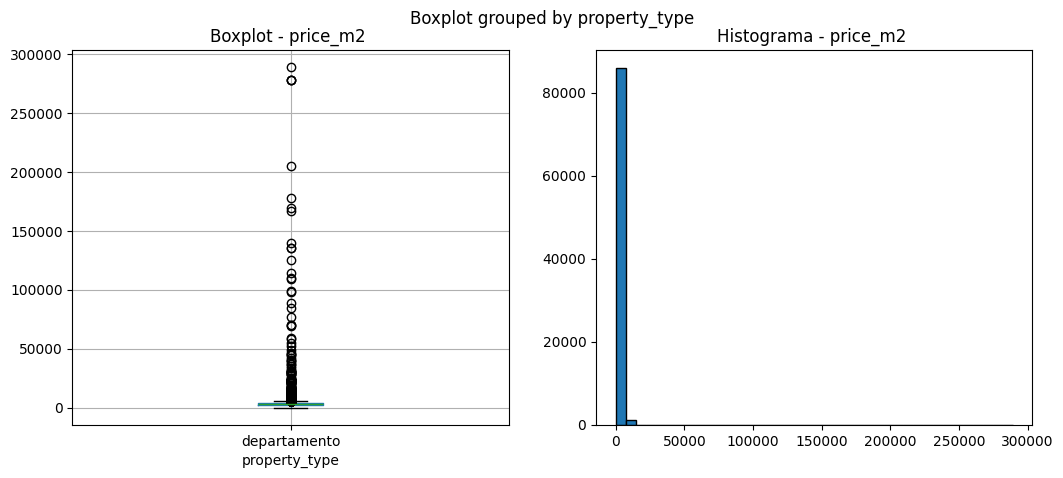

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type" ,column="price_m2", ax=ax1)
ax1.set_title("Boxplot - price_m2 ")

ax2.hist(df_ent["price_m2"], bins=40, edgecolor='black')
ax2.set_title("Histograma - price_m2 ")

plt.show()

In [8]:
print("Media de precio por metros cuadrados:", df_ent["price_m2"].mean())
print("Mediana de precio por metros cuadrados:", df_ent["price_m2"].median())
print("Moda de precio por metros cuadrados:", df_ent["price_m2"].mode()[0])

Media de precio por metros cuadrados: 3040.6854630342928
Mediana de precio por metros cuadrados: 2750.0
Moda de precio por metros cuadrados: 2500.0


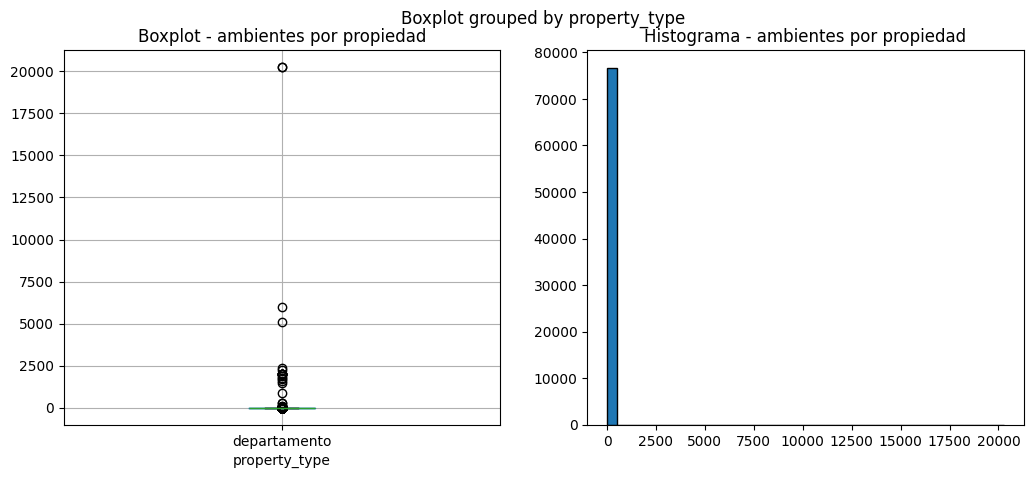

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="c_ambientes", ax=ax1)
ax1.set_title("Boxplot - ambientes por propiedad")

ax2.hist(df_ent["c_ambientes"], bins=40, edgecolor='black')
ax2.set_title("Histograma - ambientes por propiedad")

plt.show()

In [35]:
print("Media de ambientes:", df_ent["c_ambientes"].mean())
print("Mediana de ambientes:", df_ent["c_ambientes"].median())
print("Moda de ambientes:", df_ent["c_ambientes"].mode()[0])

Media de ambientes: 3.964772123921123
Mediana de ambientes: 3.0
Moda de ambientes: 2.0


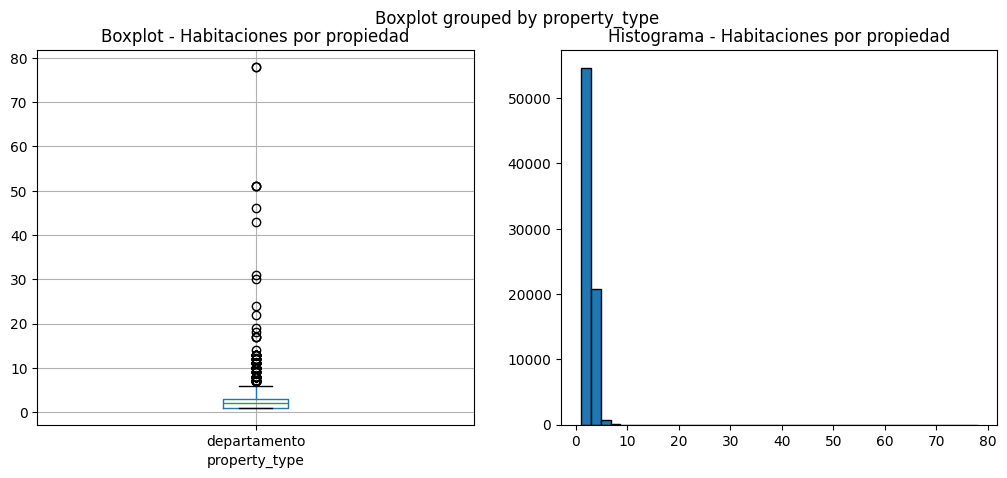

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="c_dormitorios", ax=ax1)
ax1.set_title("Boxplot - Habitaciones por propiedad")

ax2.hist(df_ent["c_dormitorios"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Habitaciones por propiedad")

plt.show()

In [36]:
print("Media de dormitorios:", df_ent["c_dormitorios"].mean())
print("Mediana de dormitorios:", df_ent["c_dormitorios"].median())
print("Moda de dormitorios:", df_ent["c_dormitorios"].mode()[0])

Media de dormitorios: 2.1272417679341435
Mediana de dormitorios: 2.0
Moda de dormitorios: 2.0


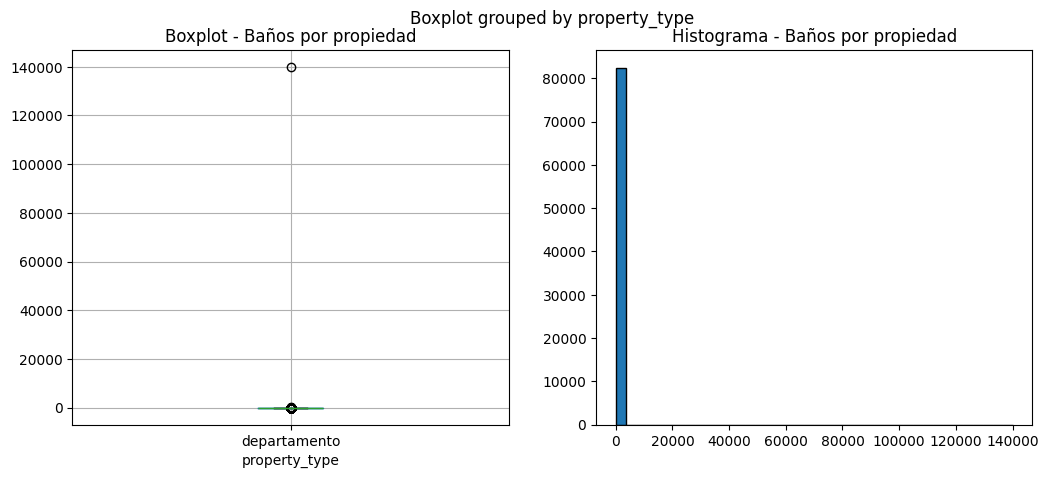

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="c_baños", ax=ax1)
ax1.set_title("Boxplot - Baños por propiedad")

ax2.hist(df_ent["c_baños"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Baños por propiedad")

plt.show()

In [12]:
print("Media de baños:", df_ent["c_baños"].mean())
print("Mediana de baños:", df_ent["c_baños"].median())
print("Moda de baños:", df_ent["c_baños"].mode()[0])

Media de baños: 3.1934056072953045
Mediana de baños: 1.0
Moda de baños: 1.0


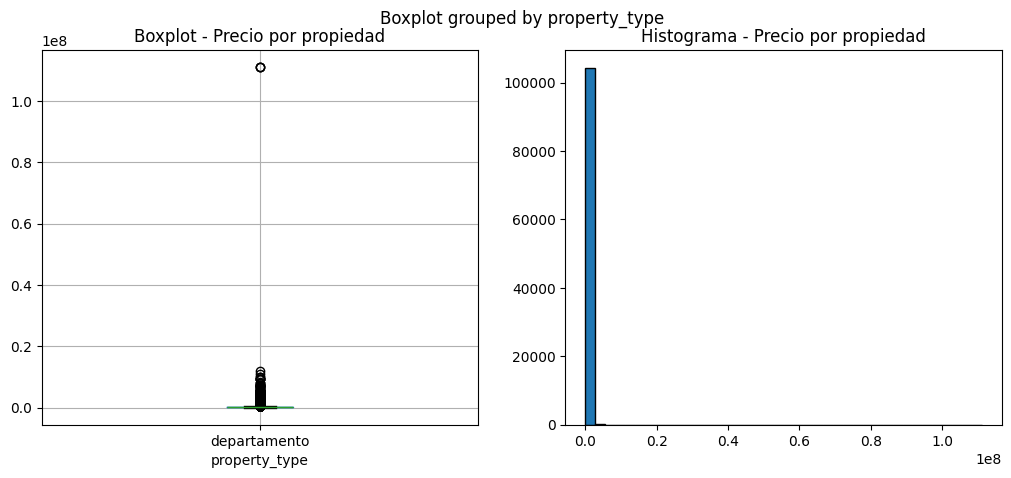

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="price", ax=ax1)
ax1.set_title("Boxplot - Precio por propiedad")

ax2.hist(df_ent["price"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Precio por propiedad")

plt.show()

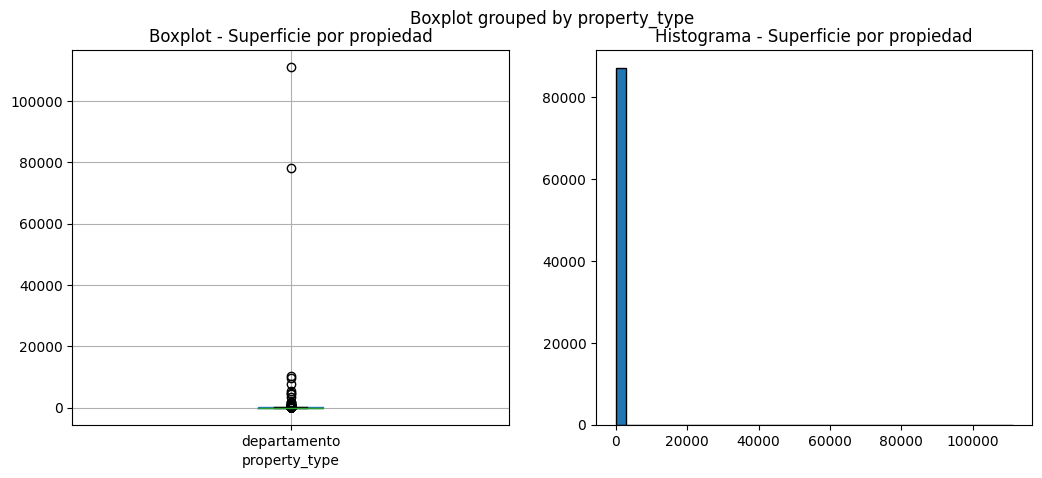

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="superficie", ax=ax1)
ax1.set_title("Boxplot - Superficie por propiedad")

ax2.hist(df_ent["superficie"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Superficie por propiedad")

plt.show()

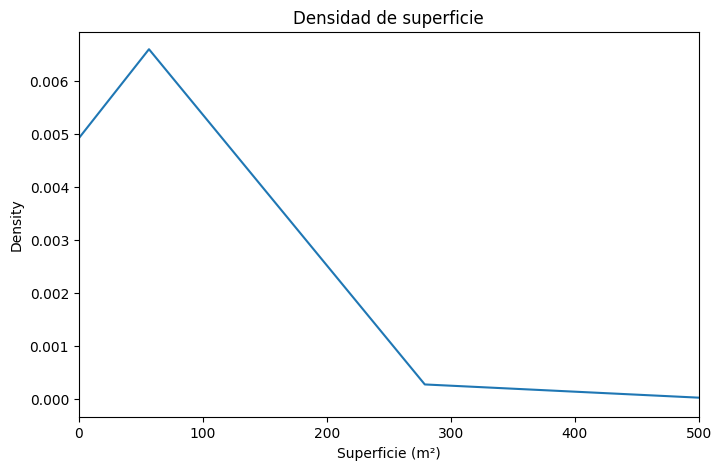

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
df_ent["superficie"].plot(kind="density", ax=ax)
ax.set_title("Densidad de superficie")
ax.set_xlabel("Superficie (m²)")
ax.set_xlim(0, 500)
plt.show()

In [38]:
print("Media de superficie:", df_ent["superficie"].mean())
print("Mediana de superficie:", df_ent["superficie"].median())
print("Moda de superficie:", df_ent["superficie"].mode()[0])

Media de superficie: 81.3304605851679
Mediana de superficie: 57.0
Moda de superficie: 40.0


**Detección por rango intercuartil**\
Muestra una mayor cantidad de valores atípicos en el precio de los departamientos.

In [9]:
def detect_atipico_iqr(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lim_inf = q1 - (iqr * 1.5)
    lim_sup = q3 + (iqr * 1.5)
    return (x < lim_inf) | (x > lim_sup)
    
def detect_atipico_iqr_2(x):
    lim_inf, lim_sup = np.percentile(x, [5, 99])
    # iqr = q3 - q1
    # lim_inf = q1
    # lim_sup = q3
    return (x < lim_inf) | (x > lim_sup)

In [10]:
# df_ent["superficie"] = df_ent.loc[(df_ent["superficie"] < 1500) & (df_ent["superficie"] > 4), "superficie"]
outlier_casa_sup =((df_ent["property_type"] == "casa") & 
                             ((df_ent["superficie"] > 800) | (df_ent["superficie"] < 30)))
outlier_departamento_sup = ((df_ent["property_type"] == "departamento") & 
                                      ((df_ent["superficie"] > 200) | (df_ent["superficie"] < 30)))

In [11]:
# me quedo con percentil 5 y 99 de superficie, porque más de 400 m2 no tiene sentido.
df_ent = df_ent[~outlier_casa_sup]
df_ent = df_ent[~outlier_departamento_sup]

C:\Users\mbustos_lightech\AppData\Local\Temp\ipykernel_15992\2564995720.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ent = df_ent[~outlier_departamento_sup]


In [12]:
# me quedo con los que tienen menos de 10 dormitorios, porque más de 10 no tiene sentido.
df_ent = df_ent[df_ent["c_dormitorios"] < 10]

# me quedo con los que tienen menos de 11 ambientes, porque más de 11 no tiene sentido.
df_ent = df_ent[df_ent["c_ambientes"] < 11]

# me quedo con los que tienen menos de 5 baños, porque más de 5 no tiene sentido.
df_ent = df_ent[df_ent["c_baños"] < 5]

# # me quedo con percentil 5 y 99 de superficie, porque más de 400 m2 no tiene sentido.
# outliers_iqr_superficie = detect_atipico_iqr_2(df_ent["superficie"])
# df_ent = df_ent[~outliers_iqr_superficie]

# me quedo con percentil 5 y 99 de precio, porque más de 2000000 no tiene sentido.
outliers_iqr_precio = detect_atipico_iqr_2(df_ent["price"])
df_ent = df_ent[~outliers_iqr_precio]

df_ent.shape

(95509, 50)

Analizo precio de la propiedad por Barrio

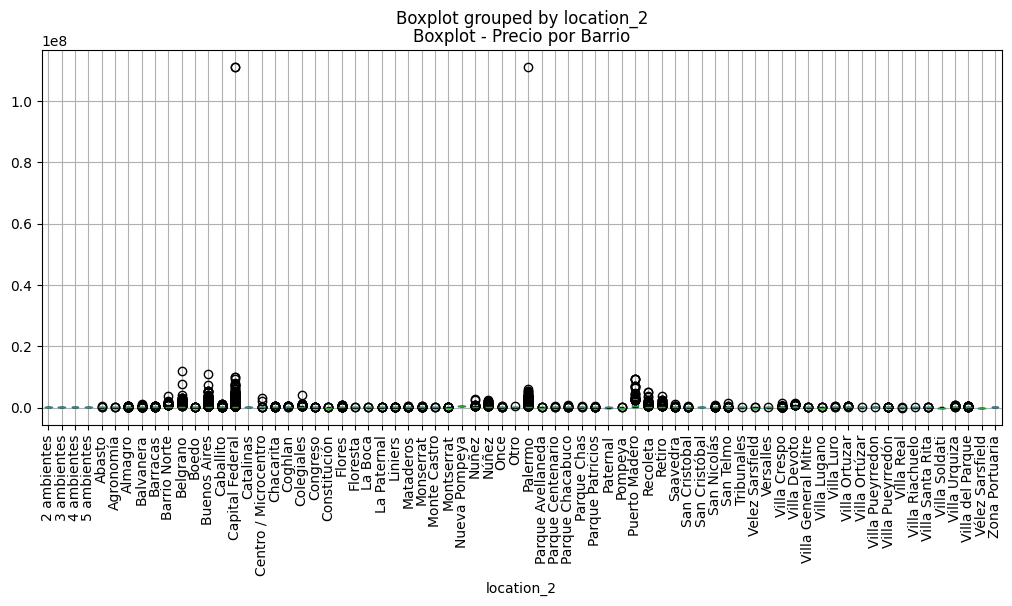

In [15]:
fig, ax1 = plt.subplots(figsize=(12, 5))

df_ent.boxplot(by="location_2", column="price", ax=ax1)
ax1.set_title("Boxplot - Precio por Barrio")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


plt.show()

Se observa en el campo barrio (location_2): 2 ambientes, 3 ambientes, 4 ambientes, 5 ambientes
Se observa outliers en location_2: Palermo, Capital Federal, Buenos Aires, Villa Crespo y Villa Urquiza principalmente.


## 2.4. Imputación de valores perdidos

Me voy a enfocar en las siguientes variables:
1. description       106184 non-null  object
2.   address           105719 non-null  object
3.   lat               44691 non-null   float64
4.   lon               44692 non-null   float64
5.   publication_date  44692 non-null   object
6.   publisher_id      75848 non-null   float64
7.   features
8. source            104804 non-null  object  

In [6]:
# Address NA se imputa con "sin info"
df_ent["address"] = df_ent["address"].fillna("sin info")

# Description NA se imputa con "sin info"
df_ent["description"] = df_ent["description"].fillna("sin info")

# La moda de primera mano no sirve, porque el dato es basura (photo)
# Me quedo con el segundo valor de la moda "23 nov 2022"
df_ent.loc[df_ent['publication_date'] == "photo", "publication_date"] = "23 nov 2022"
# Ahora reemplazo los NA con la moda
public_dat_moda = df_ent['publication_date'].mode()[0]
df_ent['publication_date'] = df_ent['publication_date'].fillna(public_dat_moda)


# Imputo PUBLISHER por la moda
publi_id_moda = df_ent["publisher_id"].mode()[0]
df_ent["publisher_id"] = df_ent["publisher_id"].fillna(publi_id_moda)
# casteo a entero
df_ent["publisher_id"] = df_ent["publisher_id"].astype(int)


# Imputo FEATURES con "sin info"
df_ent["features"] = df_ent["features"].fillna("sin info")

# imputo SOURCE con "sin info"
df_ent["source"] = df_ent["source"].fillna("sin info")

###################################################
#            Variables cuantitativas              #
###################################################
# imputo cantidad de DORMITORIOS con la moda
# df_ent["c_dormitorios"] = df_ent["c_dormitorios"].astype(int, errors="ignore") # convierto a numerico
cant_dormitorio_moda = int(df_ent["c_dormitorios"].mode()[0]) # calculo la moda
df_ent["c_dormitorios"] = df_ent["c_dormitorios"].fillna(cant_dormitorio_moda)


# Imputo cantidad BAÑOS con la moda
banio_moda = 1
df_ent["c_baños"] = df_ent["c_baños"].fillna(banio_moda)

# # # imputo SUPERFICIE con mediana
# superficie_promedio = df_ent['superficie'].median().round(2)  # mediana
# df_ent['superficie'] = df_ent['superficie'].fillna(superficie_promedio)

# imputo cantidad de AMBIENTES con la moda
hambientes_moda = int(df_ent["c_ambientes"].mode()[0])       # calculo la moda
df_ent["c_ambientes"] = df_ent["c_ambientes"].fillna(hambientes_moda)

# dataframe location_2 con lon y lat
# geo = df_ent.groupby(by=["location_2"])[["lon", "lat"]].median().reset_index()
# # me quedo con el promedio por tipo de propiedad y barrio.
# df_ent = df_ent[df_ent.columns.drop(["lon", "lat"])].merge(geo, on=["location_2"], how="left")

print(df_ent.isna().sum().sort_values(ascending=False))

location_4                    97314
lat                           60727
lon                           60726
superficie                    17257
location_3                    16686
location_2                        2
address                           0
publication_date                  0
location_0                        0
features                          0
publisher_id                      0
location_1                        0
operation_type                    0
property_type                     0
source                            0
description                       0
price                             0
currency_type                     0
c_dormitorios                     0
texto                             0
c_baños                           0
c_ambientes                       0
con_pileta                        0
con_jardin                        0
con_seguridad                     0
con_gas                           0
con_ascensor                      0
con_lavadero                

In [7]:
df_ent = df_ent.dropna(subset=["superficie"])

In [8]:
# Mostrar solo las columnas que tienen valores faltantes y su conteo
na_counts = df_ent.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
na_counts

location_4    80938
lat           51317
lon           51316
location_3    15831
location_2        1
dtype: int64

In [15]:
df_ent.shape

(87323, 48)

El precio por metro cuadrado lo voy a calcular luego de imputar los **barrios (location_3)**

### Imputación con Geopandas
Conversión a GeoDataFrame

Para operar geográficamente, transformamos el DataFrame de Pandas a un **GeoDataFrame** de GeoPandas, definiendo la columna `geometry` a partir de las columnas `lat` y `lon`.

In [9]:
df = df_ent.copy()

# Eliminamos registros sin coordenadas
df = df.dropna(subset=["lat", "lon"])

gdf_ent = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326" # Coordenadas geográficas WGS84
)

# gdf_ent[["lon", "lat", "geometry"]].head(3)

 Trabajo con Polígonos: Barrios de CABA\
Cargamos los polígonos de los barrios desde el portal de datos abiertos de la ciudad.

In [10]:
URL_BARRIOS = "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson"
gdf_barrios = gpd.read_file(URL_BARRIOS)


In [ ]:
# Grafico "Barrios de la Ciudad Autónoma de Buenos Aires"
print(f"Cargados {len(gdf_barrios)} barrios.")
gdf_barrios.plot(figsize=(8, 8), edgecolor='white', color='lightblue')
plt.title("Barrios de la Ciudad Autónoma de Buenos Aires")
plt.show()

Limpieza por contorno (Outliers geográficos)

A veces los datos vienen con errores de carga en latitud/longitud. Una técnica común es filtrar puntos que caen fuera de la "envolvente convexa" (Convex Hull) de la ciudad.

In [11]:
# Disolvemos todos los barrios en un solo polígonos que representa la ciudad
caba_poly = gdf_barrios.dissolve()
caba_hull = caba_poly.convex_hull.iloc[0]

# Identificamos puntos dentro y fuera
gdf_ent['is_within'] = gdf_ent.geometry.within(caba_hull)

print(f"Puntos dentro del Hull: {gdf_ent['is_within'].sum()}")
print(f"Puntos fuera del Hull: {(~gdf_ent['is_within']).sum()}")

Puntos dentro del Hull: 35919
Puntos fuera del Hull: 87


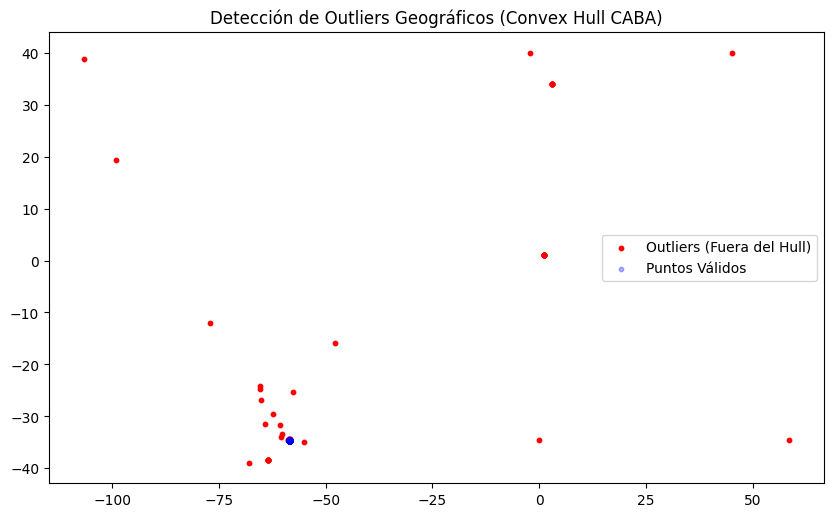

In [19]:
# Visualización de la limpieza geográfica
fig, ax = plt.subplots(figsize=(10, 8))
gdf_barrios.plot(ax=ax, color='lightgray', edgecolor='white')

# Graficamos puntos de fuera en rojo y dentro en azul (usando una muestra para no saturar)
gdf_ent[~gdf_ent['is_within']].plot(ax=ax, color='red', markersize=10, label='Outliers (Fuera del Hull)')
gdf_ent[gdf_ent['is_within']].plot(ax=ax, color='blue', markersize=10, alpha=0.3, label='Puntos Válidos')

plt.title("Detección de Outliers Geográficos (Convex Hull CABA)")
plt.legend()
plt.show()

In [12]:
# Aplicamos el filtro definitivo
gdf_ent = gdf_ent[gdf_ent['is_within']].copy()
gdf_ent = gdf_ent.drop(columns=['is_within'])
print(f"Filas finales después de limpieza geográfica: {gdf_ent.shape[0]}")

Filas finales después de limpieza geográfica: 35919


Spatial Join: Imputación de Barrios

Muchos registros tienen el barrio (`location_3`) como nulo o incorrecto. Utilizaremos un **Spatial Join** para asignar el barrio real basado en las coordenadas de la propiedad.

In [14]:
# Estado inicial de location_3
missing_before = gdf_ent["location_3"].isna().sum()
print(f"Propiedades con location_3 nulo ANTES del join: {missing_before}")

# Realizamos el join espacial
# how='left' mantiene todas las propiedades
# predicate='within' busca en qué barrio cae el punto
gdf_ent = gpd.sjoin(gdf_ent, gdf_barrios[['nombre', 'geometry']], how='left', predicate='within')

# Reemplazamos location_3 por el nombre del barrio obtenido del join
gdf_ent['location_3'] = gdf_ent['nombre']
gdf_ent = gdf_ent.drop(columns=['index_right', 'nombre'])

missing_after = gdf_ent["location_3"].isna().sum()
print(f"Propiedades con location_3 nulo DESPUÉS del join: {missing_after}")

print("\nTop 5 barrios con más publicaciones (imputados):")
print(gdf_ent['location_3'].value_counts().head())

Propiedades con location_3 nulo ANTES del join: 15563
Propiedades con location_3 nulo DESPUÉS del join: 1

Top 5 barrios con más publicaciones (imputados):
location_3
Palermo      5383
Belgrano     3453
Recoleta     3214
Caballito    2658
Almagro      2356
Name: count, dtype: int64


**Recuperación de Registros mediante Imputación Espacial**

En el Paso 3, descartamos muchos registros por falta de coordenadas. Sin embargo, si el registro tiene información del barrio (`location_3`), podemos recuperar su posición aproximada utilizando la media espacial (centroide) del barrio.

In [ ]:
barrios_a_reemplazar = {
    "Barrio Norte":"Recoleta",
    "San Nicolás" : "San Nicolas",
    "Villa del Parque" : "Villa Del Parque",
    "Centro" : "San Nicolas",
    "Congreso" : "Monserrat",
    "Boca" : "La Boca",
    "Once" : "Balvanera",
    "Abasto" :  "Almagro",
    "Villa General Mitre" : "Villa Gral. Mitre",
    "Pompeya" : "Nueva Pompeya",
    "Parque Centenario" :  "Caballito",
    "Palermo Viejo" : "Palermo",
    "Almagro Norte" :  "Almagro", 
    "Palermo Hollywood" : "Palermo"
}
df_ent["location_3"] = df_ent["location_3"].replace(barrios_a_reemplazar)
# Reiniciamos el dataframe para demostrar la recuperación
df_missing = df_ent.copy()

# Identificamos registros sin lat/lon pero que SÍ tienen barrio (location_3)
registros_imputables = (df_missing["lat"].isna() | df_missing["lon"].isna()) & df_missing["location_3"].notna()
print(f"Registros candidatos a recuperación: {registros_imputables.sum()}")

# Calculamos los centroides de cada barrio (media espacial del polígono)
gdf_barrios_idx = gdf_barrios.set_index("nombre")
centroids = gdf_barrios_idx.geometry.centroid
# centroids 

Registros candidatos a recuperación: 51123


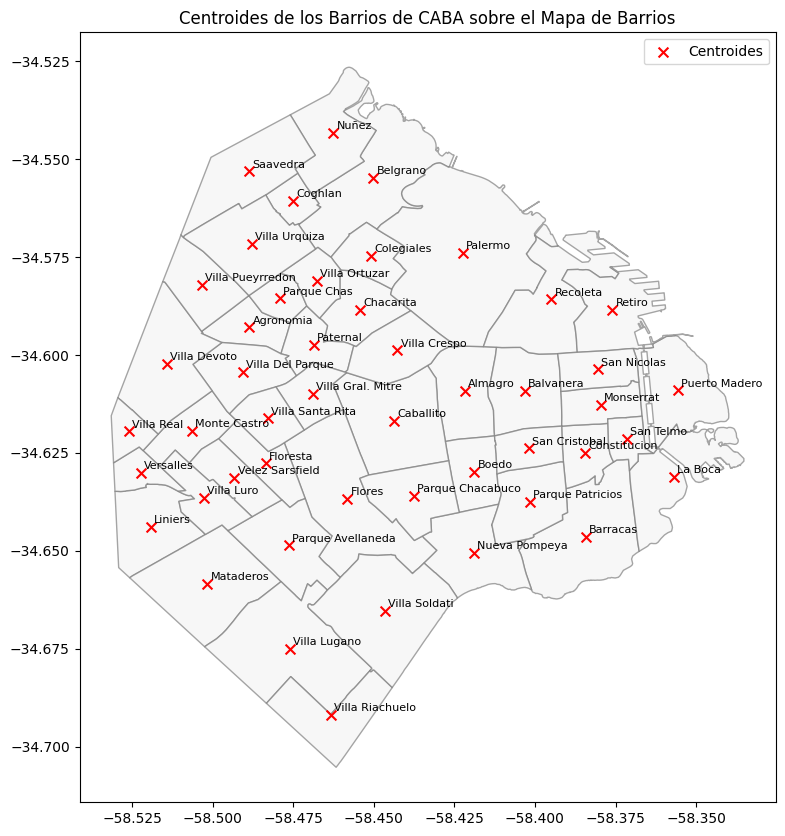

In [17]:
# Convertimos los centroides en un GeoDataFrame para graficar
gdf_centroids = gpd.GeoDataFrame(
    geometry=centroids,
    crs=gdf_barrios.crs
)

fig, ax = plt.subplots(figsize=(10, 10))
gdf_barrios.plot(ax=ax, color='whitesmoke', edgecolor='gray', alpha=0.7)
gdf_centroids.plot(ax=ax, color='red', marker='x', markersize=50, label='Centroides')

for nombre, point in gdf_centroids.geometry.items():
    ax.text(point.x + 0.001, point.y + 0.001, nombre, fontsize=8, color='black')

plt.title("Centroides de los Barrios de CABA sobre el Mapa de Barrios")
plt.legend()
plt.show()

In [18]:
# Mapeamos los centroides a los registros faltantes
df_imputed = df_missing[registros_imputables].copy()
df_imputed["lat"] = df_imputed["location_3"].map(lambda barrio: centroids[barrio].y if barrio in centroids.index else np.nan)
df_imputed["lon"] = df_imputed["location_3"].map(lambda barrio: centroids[barrio].x if barrio in centroids.index else np.nan)

In [19]:
# Verificamos cuántos pudimos recuperar
recovered_count = df_imputed["lat"].notna().sum()
print(f"Registros recuperados exitosamente: {recovered_count}")

# Mostrar los primeros registros recuperados
# df_imputed.head(5)

Registros recuperados exitosamente: 51121


In [29]:
df_imputed["lat"].isna().sum()

np.int64(2)

In [20]:
print(f'Dimensiones de gdf_ent: {gdf_ent.shape[0]} filas, {gdf_ent.shape[1]} columnas')
print(f'Dimensiones de df_imputed: {df_imputed.shape[0]} filas, {df_imputed.shape[1]} columnas')

Dimensiones de gdf_ent: 35919 filas, 49 columnas
Dimensiones de df_imputed: 51123 filas, 48 columnas


In [21]:
# Concatenamos el dataframe limpio y el dataframe de imputados para futuras etapas
df_ent_geopandas = pd.concat([gdf_ent.drop(columns="geometry"), df_imputed])
print(f'Dimensiones de df_ent_geopandas: {df_ent_geopandas.shape[0]} filas, {df_ent_geopandas.shape[1]} columnas')

Dimensiones de df_ent_geopandas: 87042 filas, 48 columnas


In [22]:
# Mostrar solo las columnas que tienen valores faltantes y su conteo
na_counts = df_ent_geopandas.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
na_counts

location_4    80658
lat               2
lon               2
location_2        1
location_3        1
dtype: int64

In [39]:
df_ent_geopandas.shape

(104296, 49)

In [23]:
df_ent_geopandas.dropna(subset=["lat", "lon"], inplace=True)
df_ent_geopandas.shape

(87040, 48)

Hasta acá, impute todo lo que necesitaba. 
Lat, lon, barrios, y superficies.
Ahora necesito sacar OUTLIERS para hacer limpieza.

In [24]:
df_ent = df_ent_geopandas.copy()

## 2.3. Tratamiento de valores atípicos

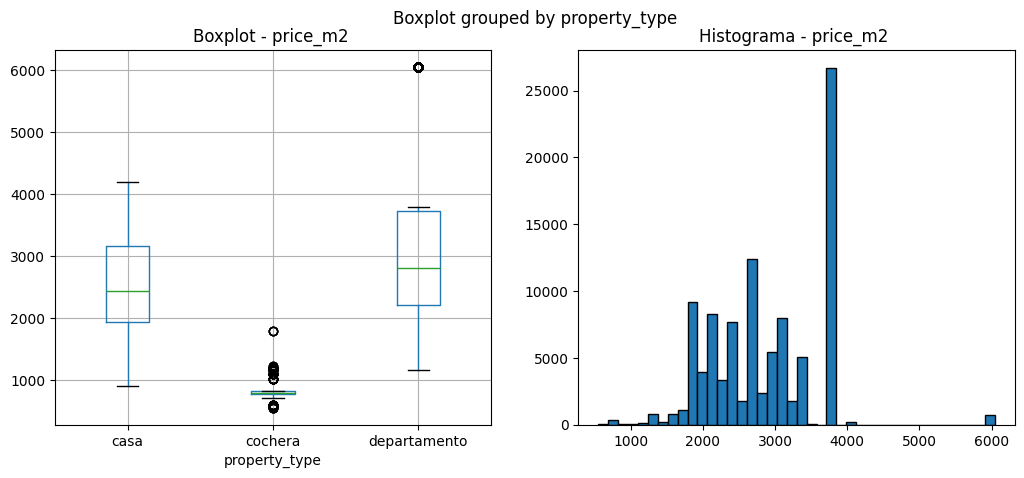

In [150]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="price_m2", ax=ax1)
ax1.set_title("Boxplot - price_m2 ")

ax2.hist(df_ent["price_m2"], bins=40, edgecolor='black')
ax2.set_title("Histograma - price_m2 ")

plt.show()

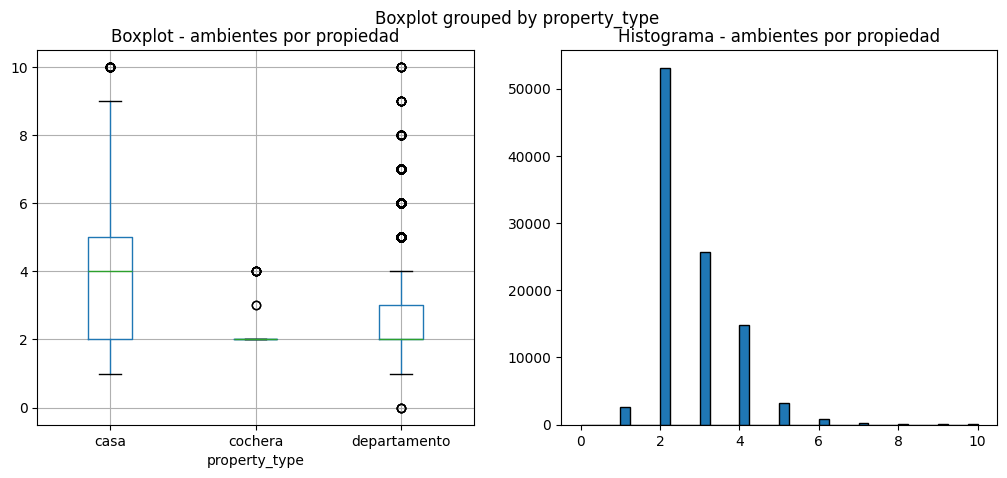

In [142]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="c_ambientes", ax=ax1)
ax1.set_title("Boxplot - ambientes por propiedad")

ax2.hist(df_ent["c_ambientes"], bins=40, edgecolor='black')
ax2.set_title("Histograma - ambientes por propiedad")

plt.show()

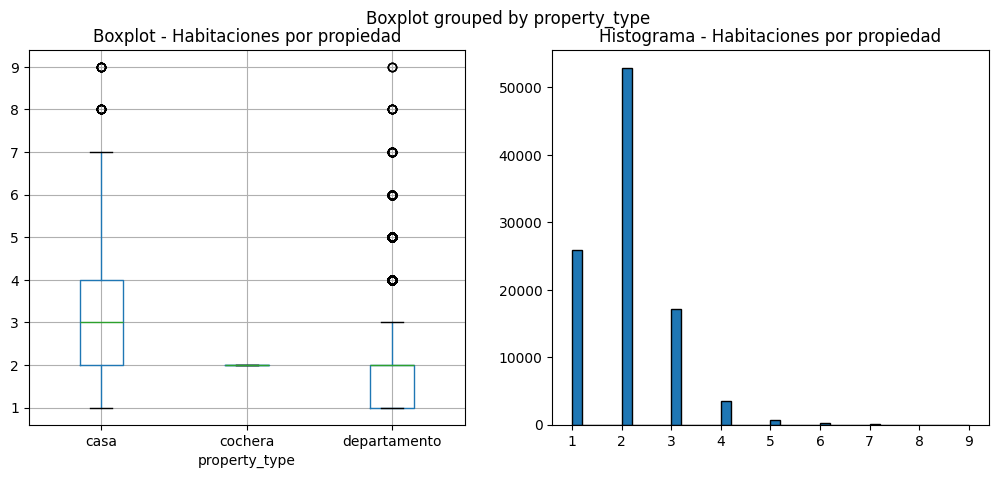

In [143]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="c_dormitorios", ax=ax1)
ax1.set_title("Boxplot - Habitaciones por propiedad")

ax2.hist(df_ent["c_dormitorios"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Habitaciones por propiedad")

plt.show()

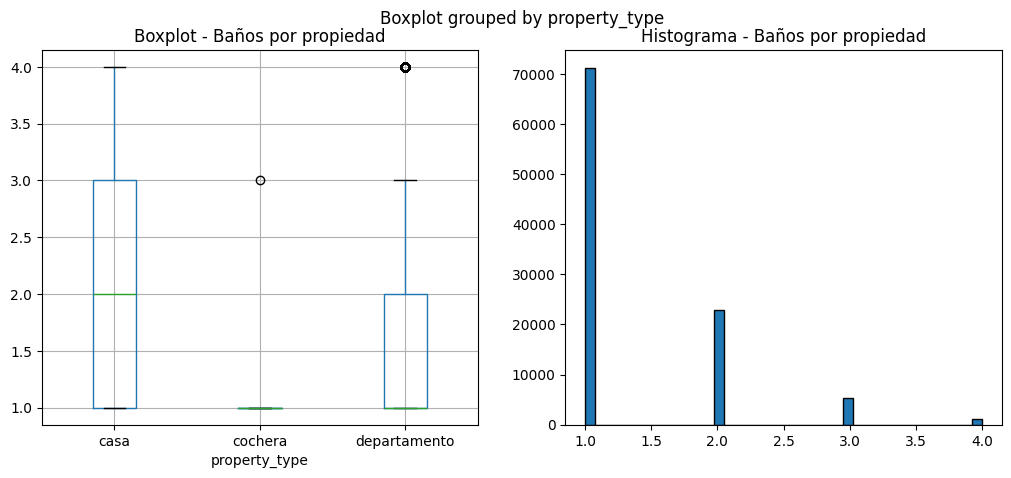

In [144]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="c_baños", ax=ax1)
ax1.set_title("Boxplot - Baños por propiedad")

ax2.hist(df_ent["c_baños"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Baños por propiedad")

plt.show()

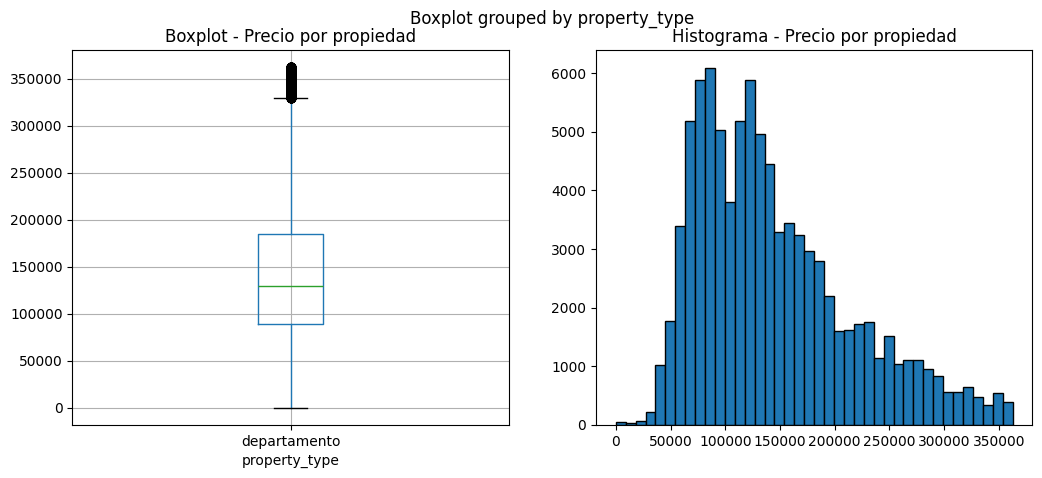

In [77]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="price", ax=ax1)
ax1.set_title("Boxplot - Precio por propiedad")

ax2.hist(df_ent["price"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Precio por propiedad")

plt.show()

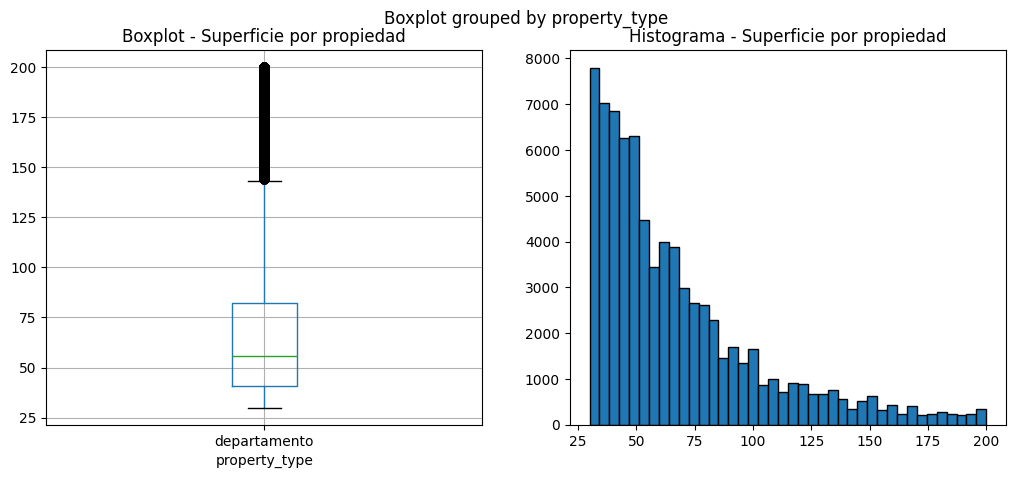

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="superficie", ax=ax1)
ax1.set_title("Boxplot - Superficie por propiedad")

ax2.hist(df_ent["superficie"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Superficie por propiedad")

plt.show()

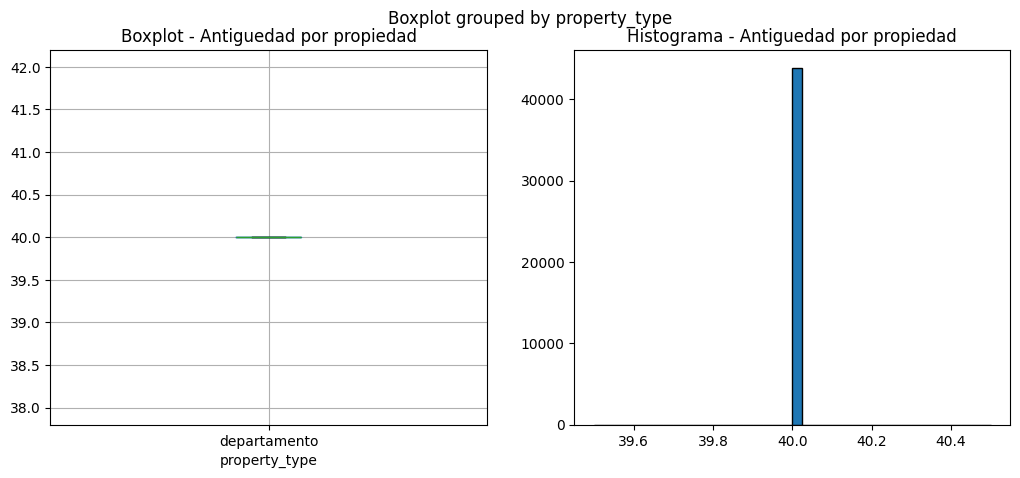

In [83]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_ent.boxplot(by="property_type", column="antiguedad", ax=ax1)
ax1.set_title("Boxplot - Antiguedad por propiedad")

ax2.hist(df_ent["antiguedad"], bins=40, edgecolor='black')
ax2.set_title("Histograma - Antiguedad por propiedad")

plt.show()

**Detección por rango intercuartil**\
Muestra una mayor cantidad de valores atípicos en el precio de los departamientos.

In [25]:
def detect_atipico_iqr(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lim_inf = q1 - (iqr * 1.5)
    lim_sup = q3 + (iqr * 1.5)
    return (x < lim_inf) | (x > lim_sup)
    
def detect_atipico_iqr_2(x):
    lim_inf, lim_sup = np.percentile(x, [5, 99])
    # iqr = q3 - q1
    # lim_inf = q1
    # lim_sup = q3
    return (x < lim_inf) | (x > lim_sup)

def detect_atipico_iqr3(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lim_inf = q1 - (iqr * 1.5)
    lim_sup = q3 + (iqr * 1.5)
    return [lim_inf, lim_sup]

In [82]:
# outlier intercuartil
# outliers_iqr_antiguedad 
df_ent["antiguedad"] = df_ent["antiguedad"].fillna(df_ent["antiguedad"].median())
outliers_iqr_antiguedad = detect_atipico_iqr(df_ent["antiguedad"])
df_ent = df_ent[~outliers_iqr_antiguedad]


In [27]:
outlier_departamento_sup = ((df_ent["property_type"] == "departamento") & 
                                      ((df_ent["superficie"] > 200) | (df_ent["superficie"] < 30)))
df_ent = df_ent[~outlier_departamento_sup]

In [26]:
# me quedo con los que tienen menos de 10 dormitorios, porque más de 10 no tiene sentido.
df_ent = df_ent[df_ent["c_dormitorios"] < 10]

# me quedo con los que tienen menos de 11 ambientes, porque más de 11 no tiene sentido.
df_ent = df_ent[df_ent["c_ambientes"] < 11]

# me quedo con los que tienen menos de 5 baños, porque más de 5 no tiene sentido.
df_ent = df_ent[df_ent["c_baños"] < 5]

df_ent.shape

(86474, 48)

In [ ]:
# Esto es mas brusco para la superficie
outliers_iqr_superficie = detect_atipico_iqr(df_ent["superficie"])
df_ent = df_ent[~outliers_iqr_superficie]
df_ent.shape

In [28]:


# me quedo con percentil 5 y 99 de precio, porque más de 2000000 no tiene sentido.
outliers_iqr_precio = detect_atipico_iqr_2(df_ent["price"])
df_ent = df_ent[~outliers_iqr_precio]

df_ent.shape

(74090, 48)

In [29]:
# Eliminar filas que en ciudad sea igual a 2,3,4 o 5 ambientes
# porque no tiene sentido que una cochera tenga más de 5 ambientes.
condicion = (df_ent["location_2"].str.contains("ambiente"))
df_ent = df_ent[~condicion]

# Verificar
df_ent.shape

(74084, 48)

In [79]:
df_ent.shape

(88829, 48)

Analizo precio de la propiedad por Barrio

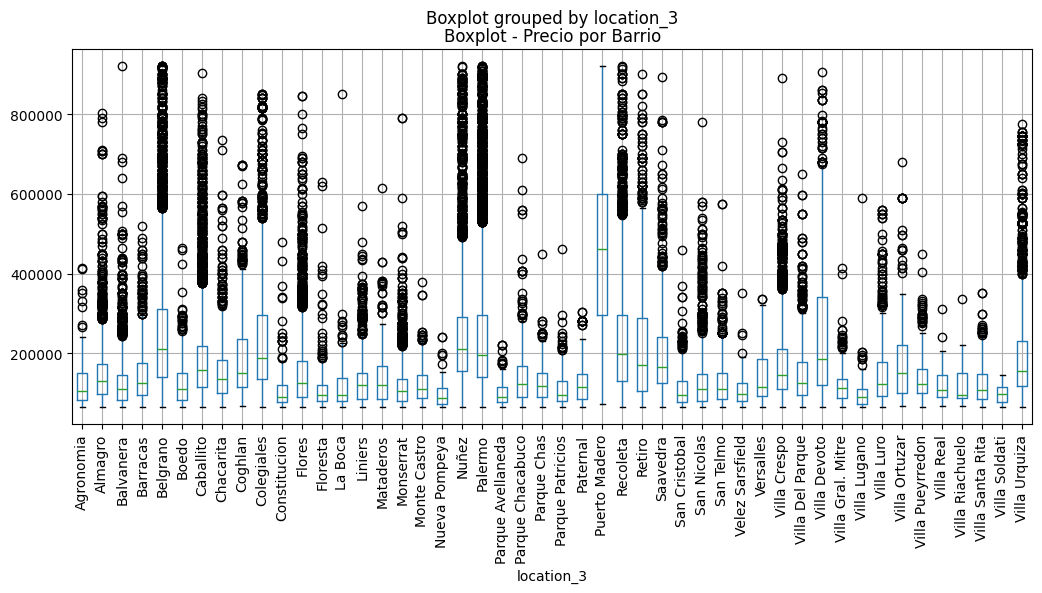

In [30]:
fig, ax1 = plt.subplots(figsize=(12, 5))

df_ent.boxplot(by="location_3", column="price", ax=ax1)
ax1.set_title("Boxplot - Precio por Barrio")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


plt.show()

<Axes: xlabel='price_total', ylabel='price'>

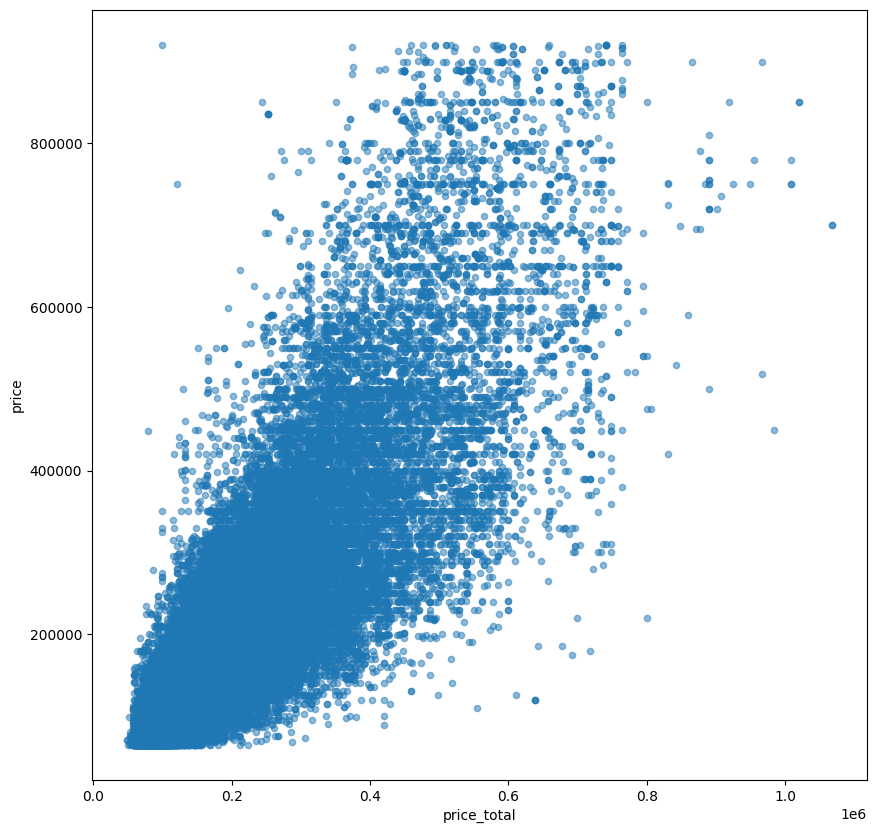

In [35]:
df_ent.plot(kind="scatter", x="price_total", y="price", alpha=0.5, figsize=(10, 10))

Se observa en el campo barrio (location_2): 2 ambientes, 3 ambientes, 4 ambientes, 5 ambientes
Se observa outliers en location_2: Palermo, Capital Federal, Buenos Aires, Villa Crespo y Villa Urquiza principalmente.


## 2.5. Campos calculados

In [ ]:
# creo la variable precio por metro cuadrado
df_ent["price_m2"] = df_ent["price"] / (df_ent["superficie"])
gb = df_ent.groupby(by=["property_type", "location_3"])["price_m2"].mean().reset_index()
    
# me quedo con el promedio por tipo de propiedad y barrio.
df_ent = df_ent[df_ent.columns.drop("price_m2")].merge(gb, on=["property_type", "location_3"], how="left")

# filtro lo que tiene un precio por metro cuadrado sin sentido para calular la estadistica
# df_ent = df_ent[(df_ent["price_m2"] >= 300) & (df_ent["price_m2"] <= 9000)]
# df_ent = df_ent[(df_ent["price_m2"] >= 300) ]


df_ent["price_total"] = df_ent["price_m2"] * (df_ent["superficie"])

In [34]:
# creo la variable con_suite que indica si el texto tiene la palabra suite o no,
#  porque es un dato que puede ser relevante para el precio.
df_ent["con_suite"] = 0
df_ent.loc[df_ent["texto"].str.contains("suite"), "con_suite"] = 1

df_ent["con_amenities"] = 0
df_ent.loc[df_ent["texto"].str.contains("amenities"), "con_amenities"] = 1

df_ent["con_dependencia"] = 0
df_ent.loc[df_ent["texto"].str.contains("dependencia"), "con_dependencia"] = 1

df_ent["monoambiente"] = 0
df_ent.loc[df_ent["texto"].str.contains("monoambiente"), "monoambiente"] = 1

df_ent["palier_privado"] = 0
df_ent.loc[df_ent["texto"].str.contains("palier privado"), "palier_privado"] = 1

df_ent["palier_privado"] = 0
df_ent.loc[df_ent["texto"].str.contains("palier privado"), "palier_privado"] = 1

df_ent["con_lavadero"] = 0
df_ent.loc[df_ent["texto"].str.contains("lavadero"), "con_lavadero"] = 1

Backup

In [80]:
# Antiguedad

# Normalizar texto
texto_norm = df_ent["texto"].str.lower().str.replace("ü", "u")

# Regex más general: busca cualquier número seguido de "años" o después de "antiguedad"
patron = r"antiguedad[:\s]*([\d]+)"

# Extraer
antiguedad = texto_norm.str.extract(patron, expand=False)

# Convertir a numérico
df_ent["antiguedad"] = pd.to_numeric(antiguedad, errors="coerce")

df_ent["antiguedad"].isna().sum()

np.int64(40620)

In [84]:
df_ent.shape

(43903, 56)

## Reducción de dimensionalidad

### Eliminar columnas con baja varianza


In [36]:
from sklearn.feature_selection import chi2, SelectKBest, VarianceThreshold, RFE, SequentialFeatureSelector
df2 = df_ent.select_dtypes('number')
X = df2[df2.columns.drop('price')]
y = df2['price']
    

print(X.shape)
fs = sk.feature_selection.VarianceThreshold(threshold=0.001)
X_new = fs.fit_transform(X) # threshold = limite superior de la varianza
print(X_new.shape)

# Columnas que quedaron
selected_columns = X.columns[fs.get_support()]
print("Columnas seleccionadas:", selected_columns)

# Columnas eliminadas
removed_columns = X.columns[~fs.get_support()]
print("Columnas eliminadas:", removed_columns)

(74084, 40)
(74084, 36)
Columnas seleccionadas: Index(['lon', 'publisher_id', 'c_dormitorios', 'c_baños', 'c_ambientes',
       'superficie', 'con_pileta', 'con_jardin', 'con_seguridad', 'con_gas',
       'con_ascensor', 'con_lavadero', 'con_aire_acondicionado',
       'con_calefaccion', 'con_terraza', 'con_balcon', 'con_amoblado',
       'con_vigilancia', 'con_electricidad', 'con_ventilacion',
       'con_transporte_cercano', 'con_parque', 'con_gimnasio', 'con_sauna',
       'a_estrenar', 'con_quincho', 'cerca_subte', 'cocheara', 'luminoso',
       'price_m2', 'price_total', 'con_suite', 'con_amenities',
       'con_dependencia', 'monoambiente', 'palier_privado'],
      dtype='str')
Columnas eliminadas: Index(['lat', 'con_escuela_cercana', 'con_comercio_cercano',
       'property_type_departamento'],
      dtype='str')


### Eliminación recursiva de atributos

In [37]:
df2 = df_ent.select_dtypes('number')
# X = df2[df2.columns.drop('price')]
X = df2[selected_columns]
y = df2['price']

reg = sk.ensemble.RandomForestRegressor(max_depth=10, n_estimators=300, n_jobs=-1)

# n_features_to_select --> nro atributos a seleccionar
# step --> cuantos atributos a eliminar en cada paso
selector = sk.feature_selection.RFE(reg, n_features_to_select=25, step=1)
selector = selector.fit(X, y)

print(selector.support_)
print(selector.ranking_)
print(selector.get_feature_names_out())

[ True  True  True  True  True  True  True  True  True False False  True
 False False  True False False False  True False False False  True  True
  True  True  True  True  True  True  True  True  True  True  True False]
[ 1  1  1  1  1  1  1  1  1  2  6  1  7  9  1  8 10  5  1 12 11  4  1  1
  1  1  1  1  1  1  1  1  1  1  1  3]
['lon' 'publisher_id' 'c_dormitorios' 'c_baños' 'c_ambientes' 'superficie'
 'con_pileta' 'con_jardin' 'con_seguridad' 'con_lavadero' 'con_terraza'
 'con_electricidad' 'con_gimnasio' 'con_sauna' 'a_estrenar' 'con_quincho'
 'cerca_subte' 'cocheara' 'luminoso' 'price_m2' 'price_total' 'con_suite'
 'con_amenities' 'con_dependencia' 'monoambiente']


### Duplicados

In [159]:
df_ent = df_ent.drop_duplicates()

## Antes de entrenar, hacer backup

In [40]:
# Ante de entrenar, hacer backup
df_ent_bkp = df_ent.copy()
# df_ent = df_ent_bkp.copy()

In [52]:
columnas = ['lon', 'publisher_id', 'c_dormitorios', 'c_baños', 'c_ambientes',
       'superficie', 'con_pileta', 'con_jardin', 'con_seguridad',
       'con_lavadero', 'con_terraza', 'con_electricidad', 'con_gimnasio',
       'con_sauna', 'a_estrenar', 'con_quincho', 'cerca_subte', 'cocheara',
       'luminoso', 'price_m2', 'con_suite', 'con_amenities',
       'con_dependencia', 'monoambiente']

In [17]:
columnas

['publisher_idc_dormitoriosc_bañosc_ambientessuperficiecon_piletacon_jardincon_seguridadcon_terrazacon_gimnasiocon_saunaa_estrenarcerca_subtecochearaluminosoproperty_type_casaproperty_type_departamentolonlatprice_m2price_totalcon_suitecon_amenitiescon_dependenciamonoambiente']

## 3. Entrenamiento del modelos (AA)- ⛔⛔⛔ NO TOCAR NADA DE ESTA SECCIÓN ⛔⛔⛔

In [72]:
# La creación de modelos requiere que todo el dataframe sea numérico
# Me quedo con las columnas numéricas solamente
# df_X = df_ent.select_dtypes('number')

# X = df_X[df_X.columns.drop('price')]
X = df_ent[selector.get_feature_names_out()]
# X = df_ent[columnas]
y = df_ent['price']

In [73]:
X.columns

Index(['lon', 'publisher_id', 'c_dormitorios', 'c_baños', 'c_ambientes',
       'superficie', 'con_pileta', 'con_jardin', 'con_seguridad',
       'con_lavadero', 'con_terraza', 'con_electricidad', 'con_gimnasio',
       'con_sauna', 'a_estrenar', 'con_quincho', 'cerca_subte', 'cocheara',
       'luminoso', 'price_m2', 'price_total', 'con_suite', 'con_amenities',
       'con_dependencia', 'monoambiente'],
      dtype='str')

In [74]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

# Definimos el valor de los hiperparámetros a usar por el modelo
n_estimators = 1000
max_depth = 10

# Creamos el modelo a entrenar
reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)

# Entrenamos el modelo
_ = reg.fit(X_train, y_train)

# Cálculo del error en entrenamiento (train)
y_pred = reg.predict(X_train)
score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)

# Cálculo del error en prueba (test)
y_pred = reg.predict(X_test)
score_test  = sk.metrics.root_mean_squared_error(y_test,  y_pred)

print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f}")

n_estimators=1000 -- max_depth=10 --> score_train=49010.39 - score_test=55118.83


In [90]:
# Cálculo del error en prueba (test)
# y_pred = reg.predict(X_test)
score_test  = sk.metrics.root_mean_squared_error(np.expm1(y_test), np.expm1(y_pred))

print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f}")

n_estimators=300 -- max_depth=30 --> score_train=0.14 - score_test=62586.42


## 3.1. (Opcional) Optimización de hiperparámetros

In [44]:
### Versión con train/test split
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

best_score_test = 10**6

### Pueden cambiar los hiperparámetros, pero no el modelo
for n_estimators in [300,500]:
    for max_depth in [5,6,7,8,9,10, 20, 30 , None]:
        reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1, random_state=42)

        # Entrenamos el modelo
        _ = reg.fit(X_train, y_train)

        # Cálculo del error en entrenamiento (train)
        y_pred = reg.predict(X_train)
        score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)

        # Cálculo del error en prueba (test)
        y_pred = reg.predict(X_test)
        score_test  = sk.metrics.root_mean_squared_error(y_test,  y_pred)

        best_score_test = min(best_score_test, score_test)

        print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f} - {best_score_test=:.2f}")

n_estimators=300 -- max_depth=5 --> score_train=64546.50 - score_test=63859.85 - best_score_test=63859.85
n_estimators=300 -- max_depth=6 --> score_train=61493.29 - score_test=61579.55 - best_score_test=61579.55
n_estimators=300 -- max_depth=7 --> score_train=58622.66 - score_test=59553.32 - best_score_test=59553.32
n_estimators=300 -- max_depth=8 --> score_train=55665.22 - score_test=57965.70 - best_score_test=57965.70
n_estimators=300 -- max_depth=9 --> score_train=52486.65 - score_test=56493.88 - best_score_test=56493.88
n_estimators=300 -- max_depth=10 --> score_train=49049.64 - score_test=55159.16 - best_score_test=55159.16
n_estimators=300 -- max_depth=20 --> score_train=22202.97 - score_test=49655.66 - best_score_test=49655.66
n_estimators=300 -- max_depth=30 --> score_train=19180.90 - score_test=49625.79 - best_score_test=49625.79
n_estimators=300 -- max_depth=None --> score_train=19145.03 - score_test=49617.21 - best_score_test=49617.21
n_estimators=500 -- max_depth=5 --> scor

KeyboardInterrupt: 

In [41]:
# Versión con GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [7, 8, 9, 10],
    'min_samples_split': [2, 5, 10,20,50],
    'min_samples_leaf': [1, 5, 10],
    # 'bootstrap': [True, False]
    'max_features': ['sqrt', 'log2']
}

reg = sk.ensemble.RandomForestRegressor(random_state=42)

grid_search = sk.model_selection.GridSearchCV(reg, param_grid=param_grid, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

KeyboardInterrupt: 

## 3.2. Análisis de la importancia de variables en el modelo (opcional)

Una manera visual de entender a que variable el modelo le está prestando mayor atención.

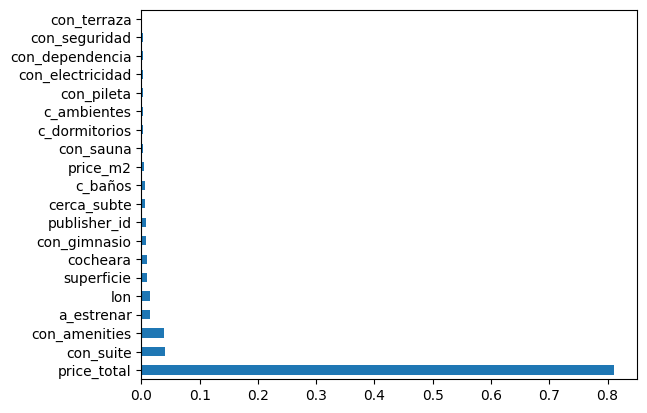

In [75]:
feat_importances = pd.Series(reg.feature_importances_, index=X.columns)

# gráfico de barras horizontales
feat_importances.nlargest(20).plot(kind='barh');

In [76]:
feat_importances.sort_values(ascending=False)

price_total         0.810481
con_suite           0.041188
con_amenities       0.038708
a_estrenar          0.015420
lon                 0.014973
superficie          0.010486
cocheara            0.009459
con_gimnasio        0.007901
publisher_id        0.007620
cerca_subte         0.006489
c_baños             0.005939
price_m2            0.004993
con_sauna           0.003542
c_dormitorios       0.003379
c_ambientes         0.002656
con_pileta          0.002590
con_electricidad    0.002216
con_dependencia     0.002207
con_seguridad       0.002197
con_terraza         0.001798
luminoso            0.001405
monoambiente        0.001188
con_jardin          0.001095
con_lavadero        0.001080
con_quincho         0.000989
dtype: float64

## 4. Solución para subir Kaggle

In [57]:
df_ap = pd.read_csv(f"{DIR_local}/a_predecir.csv", index_col="id")
# df_ap.head(2)

## 4.1 Filtro

In [53]:
filtro = (df_ap["property_type"].isin(['departamento', "departamentos"]))
df_ap = df_ap.loc[filtro]
df_ap.shape

(10817, 17)

## 4.2. Generación del archivo para Kaggle

Hacer en df_ap el mismo proceso que se realizó para los datos de entrenamiento

### **Creación de nuevos atributos**

In [58]:
# creamos otras variables
texto = (
    df_ap["features"].fillna("").astype(str) + " " +
    df_ap["description"].fillna("").astype(str)
)
# pasamos a minúscula para evitar problemas de mayúsculas/minúsculas
texto = texto.str.lower()
df_ap["texto"] = texto



# dormitorios
patron = r"(\d+) dormitorios;|dormitorio: (\d+);|dormitorios:(\d+);|(\d+)\s*habitaciones"
dormitorios = texto.str.extract(patron, expand=False)
df_ap["c_dormitorios"] = pd.to_numeric(dormitorios[0].fillna(dormitorios[1]).fillna(dormitorios[2]).fillna(dormitorios[3]))

#
# baños
patron = r"(\d+) baños;|bano: (\d+);|baños:(\d+);|(\d+)\s*banos"
banios = texto.str.extract(patron, expand=False)
df_ap["c_baños"] = pd.to_numeric(banios[0].fillna(banios[1]).fillna(banios[2]).fillna(banios[3]))

# ambientes
patron = r"(\d+)\s*(?:ambientes?|rooms?)"
ambientes = texto.str.extract(patron, expand=False)
df_ap["c_ambientes"] = pd.to_numeric(ambientes)


# # el garage solo anotaremos tiene SI(1) o NO(0)
# garage = texto.str.extract(r'(garage);|(cochera):|(cocheras):\d+')
# df_ap["garage"]  = garage[0].fillna(garage[1]).fillna(garage[2])
# df_ap["con_garage"] = int(0)
# df_ap.loc[~df_ap["garage"].isna(), "con_garage"] = int(1)

# Superficie
patron = r";(\d+)\s*m²|scubierta: (\d+);| superficie total:(\d+)m.{1};|sup.\scubierta:(\d+)\s*m²| tcubierta:\s(\d*,\d*)\sm²| superficie\stotal:\s(\d+)"
superficie = texto.str.extract(patron, expand=False)
df_ap["superficie"] = pd.to_numeric(superficie[0].fillna(superficie[1]).fillna(superficie[2]).fillna(superficie[3]).fillna(superficie[4]).fillna(superficie[5]))   

# atributos binarios
df_ap["con_pileta"] = 0
df_ap.loc[df_ap["texto"].str.contains("pileta"), "con_pileta"] = 1
df_ap["con_jardin"] = 0
df_ap.loc[df_ap["texto"].str.contains("jardin"), "con_jardin"] = 1
df_ap["con_seguridad"] = 0
df_ap.loc[df_ap["texto"].str.contains("seguridad"), "con_seguridad"] = 1
df_ap["con_gas"] = 0
df_ap.loc[df_ap["texto"].str.contains("gas"), "con_gas"] = 1
df_ap["con_ascensor"] = 0
df_ap.loc[df_ap["texto"].str.contains("ascensor"), "con_ascensor"] = 1
df_ap["con_lavadero"] = 0
df_ap.loc[df_ap["texto"].str.contains("lavadero"), "con_lavadero"] = 1
df_ap["con_aire_acondicionado"] = 0
df_ap.loc[df_ap["texto"].str.contains("aire acondicionado"), "con_aire_acondicionado"] = 1
df_ap["con_calefaccion"] = 0
df_ap.loc[df_ap["texto"].str.contains("calefaccion"), "con_calefaccion"] = 1
df_ap["con_terraza"] = 0
df_ap.loc[df_ap["texto"].str.contains("terraza"), "con_terraza"] = 1
df_ap["con_balcon"] = 0
df_ap.loc[df_ap["texto"].str.contains("balcon"), "con_balcon"] = 1
df_ap["con_amoblado"] = 0
df_ap.loc[df_ap["texto"].str.contains("amoblado"), "con_amoblado"] = 1
df_ap["con_vigilancia"] = 0
df_ap.loc[df_ap["texto"].str.contains("vigilancia"), "con_vigilancia"] = 1
df_ap["con_electricidad"] = 0
df_ap.loc[df_ap["texto"].str.contains("electricidad"), "con_electricidad"] = 1
df_ap["con_ventilacion"] = 0
df_ap.loc[df_ap["texto"].str.contains("ventilacion"), "con_ventilacion"] = 1
df_ap["con_escuela_cercana"] = 0
df_ap.loc[df_ap["texto"].str.contains("escuela cercana"), "con_escuela_cercana"] = 1
df_ap["con_transporte_cercano"] = 0
df_ap.loc[df_ap["texto"].str.contains("transporte cercano"), "con_transporte_cercano"] = 1
df_ap["con_comercio_cercano"] = 0
df_ap.loc[df_ap["texto"].str.contains("comercio cercano"), "con_comercio_cercano"] = 1
df_ap["con_parque"] = 0
df_ap.loc[df_ap["texto"].str.contains("parque"), "con_parque"] = 1
df_ap["con_gimnasio"] = 0
df_ap.loc[df_ap["texto"].str.contains("gimnasio"), "con_gimnasio"] = 1
df_ap["con_sauna"] = 0
df_ap.loc[df_ap["texto"].str.contains("sauna"), "con_sauna"] = 1
df_ap["a_estrenar"] = 0
df_ap.loc[df_ap["texto"].str.contains("a estrenar"), "a_estrenar"] = 1
df_ap["con_quincho"] = 0
df_ap.loc[df_ap["texto"].str.contains("quincho"), "con_quincho"] = 1
df_ap["cerca_subte"] = 0
df_ap.loc[df_ap["texto"].str.contains("subte"), "cerca_subte"] = 1

df_ap["cocheara"] = 0
df_ap.loc[df_ap["texto"].str.contains("cochera|cocheras|coch|garage",
                                         regex=True), "cocheara"] = 1
df_ap["luminoso"] = 0
df_ap.loc[df_ap["texto"].str.contains("luminoso"), "luminoso"] = 1

# estandarizo el tipo de propiedad para quedarnos con solo "casa" y "departamento"
casa_departamento = {
    "casas" : "casa",
    "departamentos" : "departamento"
}
df_ap["property_type"] = df_ap["property_type"].replace(casa_departamento)


# Precio por metro cuadrado promedio por tipo de propiedad y barrio.
# df_ap = df_ap[df_ap.columns].merge(gb, on=["property_type", "location_3"], how="left").set_index(df_ap.index)



# Código para label encoding acá
colnames = ['property_type']
dummies = pd.get_dummies(df_ap[colnames], dtype=int)
df_ap = pd.concat([df_ap, dummies], axis=1)

# imputo el promedio de (lat y lon) por barrio.
# df_ap = df_ap[df_ap.columns.drop(["lon", "lat"])].merge(geo, on=["location_2"], how="left").set_index(df_ap.index)
# df_ap["price_total"] = df_ap["price_m2"] * (df_ap["superficie"])

df_ap.shape

(13471, 50)

In [188]:
df_ap.shape

(13471, 50)

In [59]:

df_ap["con_suite"] = 0
df_ap.loc[df_ap["texto"].str.contains("suite"), "con_suite"] = 1

df_ap["con_amenities"] = 0
df_ap.loc[df_ap["texto"].str.contains("amenities"), "con_amenities"] = 1

df_ap["con_dependencia"] = 0
df_ap.loc[df_ap["texto"].str.contains("dependencia"), "con_dependencia"] = 1

df_ap["monoambiente"] = 0
df_ap.loc[df_ap["texto"].str.contains("monoambiente"), "monoambiente"] = 1

df_ap["palier_privado"] = 0
df_ap.loc[df_ap["texto"].str.contains("palier privado"), "palier_privado"] = 1

df_ap["con_lavadero"] = 0
df_ap.loc[df_ap["texto"].str.contains("lavadero"), "con_lavadero"] = 1

### **Imputación de valores perdidos**

In [60]:
# Address NA se imputa con "sin info"
df_ap["address"] = df_ap["address"].fillna("sin info")

# Description NA se imputa con "sin info"
df_ap["description"] = df_ap["description"].fillna("sin info")

# La moda de primera mano no sirve, porque el dato es basura (photo)
# Me quedo con el segundo valor de la moda "23 nov 2022"
df_ap.loc[df_ap['publication_date'] == "photo", "publication_date"] = "23 nov 2022"
# Ahora reemplazo los NA con la moda
public_dat_moda = df_ap['publication_date'].mode()[0]
df_ap['publication_date'] = df_ap['publication_date'].fillna(public_dat_moda)


# Imputo PUBLISHER por la moda
publi_id_moda = df_ap["publisher_id"].mode()[0]
df_ap["publisher_id"] = df_ap["publisher_id"].fillna(publi_id_moda)
# casteo a entero
df_ap["publisher_id"] = df_ap["publisher_id"].astype(int)


# Imputo FEATURES con "sin info"
df_ap["features"] = df_ap["features"].fillna("sin info")


# # imputo LOCATION 3 y 4 con "sin info"
# df_ap["location_3"].fillna("sin info", inplace=True)
# df_ap["location_4"].fillna("sin info", inplace=True)


# imputo SOURCE con "sin info"
df_ap["source"] = df_ap["source"].fillna("sin info")



# imputo cantidad de DORMITORIOS con la moda
# df_ap["c_dormitorios"] = df_ap["c_dormitorios"].astype(int, errors="ignore") # convierto a numerico
cant_dormitorio_moda = int(df_ap["c_dormitorios"].mode()[0]) # calculo la moda
df_ap["c_dormitorios"] = df_ap["c_dormitorios"].fillna(cant_dormitorio_moda)


# Imputo cantidad BAÑOS con la moda
# df_ap["c_baños"] =  df_ap["c_baños"].astype(int, errors="ignore")  # convierto a numerico
banio_moda = 1       # calculo la moda
df_ap["c_baños"] = df_ap["c_baños"].fillna(banio_moda)

# # imputo SUPERFICIE con el mediana
# df_ap['superficie'] = df_ap['superficie'].astype(float)                 # convierto a numerico
superficie_promedio = df_ap['superficie'].median().round(2)  # mediana
df_ap['superficie'] = df_ap['superficie'].fillna(superficie_promedio)

# imputo cantidad de AMBIENTES con la moda
hambientes_moda = int(df_ap["c_ambientes"].mode()[0])       # calculo la moda
df_ap["c_ambientes"] = df_ap["c_ambientes"].fillna(hambientes_moda)

# # dataframe location_2 con lon y lat
# geo = df_ap.groupby(by=["location_2"])[["lon", "lat"]].median().reset_index()
# # me quedo con el promedio por tipo de propiedad y barrio.
# df_ap = df_ap[df_ap.columns.drop(["lon", "lat"])].merge(geo, on=["location_2"], how="left").set_index(df_ap.index)

# df_ap["price_m2"] = df_ap["price_m2"].fillna(df_ap["price_m2"].mean()) 

print(df_ap.isna().sum().sort_values(ascending=False))





price                         13471
location_4                    12773
lat                            9947
lon                            9947
location_3                       54
address                           0
description                       0
features                          0
publisher_id                      0
publication_date                  0
location_1                        0
location_2                        0
operation_type                    0
property_type                     0
location_0                        0
source                            0
currency_type                     0
texto                             0
c_dormitorios                     0
c_baños                           0
c_ambientes                       0
superficie                        0
con_pileta                        0
con_jardin                        0
con_seguridad                     0
con_gas                           0
con_ascensor                      0
con_lavadero                

### Imputación con Geopandas
Conversión a GeoDataFrame

Para operar geográficamente, transformamos el DataFrame de Pandas a un **GeoDataFrame** de GeoPandas, definiendo la columna `geometry` a partir de las columnas `lat` y `lon`.

In [62]:
df = df_ap.copy()
# Eliminamos registros sin coordenadas
df = df.dropna(subset=["lat", "lon"])

gdf_ent = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326" # Coordenadas geográficas WGS84
)
gdf_ent.index.equals(df_ap.index)
# gdf_ent[["lon", "lat", "geometry"]].head(3)

False

 Trabajo con Polígonos: Barrios de CABA\
Cargamos los polígonos de los barrios desde el portal de datos abiertos de la ciudad.

**Limpieza por contorno (Outliers geográficos)**

A veces los datos vienen con errores de carga en latitud/longitud. Una técnica común es filtrar puntos que caen fuera de la "envolvente convexa" (Convex Hull) de la ciudad.

Spatial Join: Imputación de Barrios

Muchos registros tienen el barrio (`location_3`) como nulo o incorrecto. Utilizaremos un **Spatial Join** para asignar el barrio real basado en las coordenadas de la propiedad.

In [63]:
# Estado inicial de location_3
missing_before = gdf_ent["location_3"].isna().sum()
print(f"Propiedades con location_3 nulo ANTES del join: {missing_before}")

# Realizamos el join espacial
# how='left' mantiene todas las propiedades
# predicate='within' busca en qué barrio cae el punto
gdf_ent = gpd.sjoin(gdf_ent, gdf_barrios[['nombre', 'geometry']], how='left', predicate='within')

# Reemplazamos location_3 por el nombre del barrio obtenido del join
gdf_ent['location_3'] = gdf_ent['nombre']
gdf_ent = gdf_ent.drop(columns=['index_right', 'nombre'])

missing_after = gdf_ent["location_3"].isna().sum()
print(f"Propiedades con location_3 nulo DESPUÉS del join: {missing_after}")

print("\nTop 5 barrios con más publicaciones (imputados):")
print(gdf_ent['location_3'].value_counts().head())

Propiedades con location_3 nulo ANTES del join: 54
Propiedades con location_3 nulo DESPUÉS del join: 0

Top 5 barrios con más publicaciones (imputados):
location_3
Palermo         430
Belgrano        383
Recoleta        378
Villa Crespo    299
Caballito       278
Name: count, dtype: int64


**Recuperación de Registros mediante Imputación Espacial**

En el Paso 3, descartamos muchos registros por falta de coordenadas. Sin embargo, si el registro tiene información del barrio (`location_3`), podemos recuperar su posición aproximada utilizando la media espacial (centroide) del barrio.

In [64]:
# Reiniciamos el dataframe para demostrar la recuperación
df_missing = df_ap.copy()

# Identificamos registros sin lat/lon pero que SÍ tienen barrio (location_3)
registros_imputables = (df_missing["lat"].isna() | df_missing["lon"].isna()) & df_missing["location_3"].notna()
print(f"Registros candidatos a recuperación: {registros_imputables.sum()}")

Registros candidatos a recuperación: 9947


In [ ]:
# Calculamos los centroides de cada barrio (media espacial del polígono)
# gdf_barrios_idx = gdf_barrios.set_index("nombre")
# centroids = gdf_barrios_idx.geometry.centroid
# centroids 

In [ ]:
# Convertimos los centroides en un GeoDataFrame para graficar
gdf_centroids = gpd.GeoDataFrame(
    geometry=centroids,
    crs=gdf_barrios.crs
)


barrios_a_imputar = {
    'Villa del Parque': 'Villa Del Parque',
    'Barrio Norte': 'Recoleta',
    'San Nicolás': 'San Nicolas',
    'Abasto': 'Almagro',
    'Villa General Mitre': 'Villa Gral. Mitre',
    'Pompeya': 'Nueva Pompeya',
    'Centro': 'Monserrat',
    'Parque Centenario': 'Caballito',
    'Congreso': 'Monserrat',
    'Once': 'Balvanera',
    'Boca': 'La Boca'
}
df_missing["location_3"] = df_missing["location_3"].replace(barrios_a_imputar)

# Mapeamos los centroides a los registros faltantes
df_imputed = df_missing[registros_imputables].copy()
df_imputed["lat"] = df_imputed["location_3"].map(lambda barrio: centroids[barrio].y if barrio in centroids.index else np.nan)
df_imputed["lon"] = df_imputed["location_3"].map(lambda barrio: centroids[barrio].x if barrio in centroids.index else np.nan)

# Verificamos cuántos pudimos recuperar
recovered_count = df_imputed["lat"].notna().sum()
print(f"Registros recuperados exitosamente: {recovered_count}")

# # Mostrar los primeros registros recuperados
# df_imputed.head(3)

Registros recuperados exitosamente: 9947


,description,address,lat,lon,publication_date,publisher_id,features,location_0,location_1,location_2,...,cocheara,luminoso,property_type_casa,property_type_cochera,property_type_departamento,con_suite,con_amenities,con_dependencia,monoambiente,palier_privado
id,,,,,,,,,,,,,,,,,,,,,
713635,casa en lamarca al 3500 - garage 2 terrazas 2 ...,EMILIO LAMARCA al 3500,-34.602355,-58.514281,23 nov 2022,256121,sup. cubierta:150 m² cubierta; dormitorios:3 ...,Argentina,Capital Federal,Capital Federal,...,1,0,1,0,0,0,0,0,0,0
714108,lote propio cochera patio y parque ...,Oliden 1600,-34.658372,-58.501735,23 nov 2022,248157,sup. cubierta:155 m² cubierta; dormitorios:3 ...,Argentina,Capital Federal,Capital Federal,...,1,0,1,0,0,0,0,0,0,0
714284,casa 3 ambientes venta villa devoto ...,EPECUEN 4700,-34.602355,-58.514281,23 nov 2022,101283,sup. cubierta:90 m² cubierta; dormitorios:2 d...,Argentina,Capital Federal,Capital Federal,...,0,0,1,0,0,0,0,0,0,0


In [66]:
print(f'Dimensiones de gdf_ent: {gdf_ent.shape[0]} filas, {gdf_ent.shape[1]} columnas')
print(f'Dimensiones de df_imputed: {df_imputed.shape[0]} filas, {df_imputed.shape[1]} columnas')

# Concatenamos el dataframe limpio y el dataframe de imputados para futuras etapas
df_ap_geopandas = pd.concat([gdf_ent.drop(columns="geometry"), df_imputed])
print(f'Dimensiones de df_ap_geopandas: {df_ap_geopandas.shape[0]} filas, {df_ap_geopandas.shape[1]} columnas')

Dimensiones de gdf_ent: 3524 filas, 56 columnas
Dimensiones de df_imputed: 9947 filas, 55 columnas
Dimensiones de df_ap_geopandas: 13471 filas, 55 columnas


Como aún tengo registros de lon y lat por imputar, ahora voy a utilizar el campo *location_2*

In [203]:
df_imputed.index

Index([ 713635,  714108,  714284,  714645,  714753,  714863,  714924,  715132,
        715405,  715433,
       ...
       1242080, 1242082, 1242090, 1242092, 1242118, 1242119, 1242131, 1242132,
       1242135, 1242139],
      dtype='int64', name='id', length=9947)

In [67]:
df_ap = df_ap_geopandas.copy()

In [211]:
df_ap.index

Index([ 264893,  264899,  264910,  264915,  264919,  264928,  264932,  264935,
        264939,  264944,
       ...
       1242080, 1242082, 1242090, 1242092, 1242118, 1242119, 1242131, 1242132,
       1242135, 1242139],
      dtype='int64', name='id', length=13471)

### *Campos calculados*

In [68]:
# me quedo con el promedio por tipo de propiedad y barrio.
df_ap = df_ap[df_ap.columns].merge(gb, on=["property_type", "location_3"], how="left").set_index(df_ap.index)
df_ap["price_total"] = df_ap["price_m2"] * (df_ap["superficie"])

df_ap.shape

(13471, 57)

In [213]:
df_ap.index

Index([ 264893,  264899,  264910,  264915,  264919,  264928,  264932,  264935,
        264939,  264944,
       ...
       1242080, 1242082, 1242090, 1242092, 1242118, 1242119, 1242131, 1242132,
       1242135, 1242139],
      dtype='int64', name='id', length=13471)

In [77]:
X.columns

Index(['lon', 'publisher_id', 'c_dormitorios', 'c_baños', 'c_ambientes',
       'superficie', 'con_pileta', 'con_jardin', 'con_seguridad',
       'con_lavadero', 'con_terraza', 'con_electricidad', 'con_gimnasio',
       'con_sauna', 'a_estrenar', 'con_quincho', 'cerca_subte', 'cocheara',
       'luminoso', 'price_m2', 'price_total', 'con_suite', 'con_amenities',
       'con_dependencia', 'monoambiente'],
      dtype='str')

In [78]:
# # TODO: Hacer en df_ap la misma limpieza que en df_ent
# df_ap = df_ap.fillna(0)

# df_ap = df_ap.select_dtypes('number')

X_ap = df_ap[X.columns]

# Predecimos los precios del dataset a predecir
y_pred_ap = reg.predict(X_ap)
y_pred_ap

array([210002.85880729,  94874.83624786, 132626.47952082, ...,
        78437.29523574,  78197.36184062,  90139.27918499], shape=(13471,))

In [79]:
DIR_out = "/content/drive/MyDrive" + "/UBA/Especializacion/DM/Segunda-entrega/"
DIR_out_local = "../data/stage/"
# Lleno el precio de df_ap con las predicciones
df_ap["price"] = y_pred_ap
# df_ap["price"] = y_pred_ap_expm1

# Grabo el df_ap en un archivo csv para subir a Kaggle
nombre = "e4v4-all-v6"
df_ap["price"].to_csv(f"{DIR_out_local}/solucion-{nombre}.csv")